# Layer 1 Final Notebook: Crypto10K Cleansing, FinBERT Scoring, and Mutation Sweeps
Primary outputs:

- Baseline FinBERT-scored BTC/ETH Crypto10K tweets.
- Sentiment amplification sweep: `1.25`, `1.5`, `2.0`.
- Temporal jitter sweep: `+/-5`, `+/-15`, `+/-30` minutes.
- Adversarial injection sweep: `0.10`, `0.20`, `0.35` nominal injection ratios.
- Compatibility aliases for the middle settings: `crypto10k_sentiment.csv`, `crypto10k_temporal_jitter.csv`, and `crypto10k_adversarial.csv`.


In [3]:
# Optional Colab setup: clone the repo if it is not already available.
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = "https://github.com/changju784/crypto-drift-guard.git"
GITHUB_BRANCH = "layer1"
REPO_ROOT = Path("/content/crypto-drift-guard")

if not REPO_ROOT.exists():
    clone_url = REPO_URL
    token = os.environ.get("GITHUB_TOKEN")
    try:
        from google.colab import userdata  # type: ignore
        token = userdata.get("GITHUB_TOKEN") or token
    except Exception:
        pass
    if token and clone_url.startswith("https://github.com/"):
        clone_url = clone_url.replace("https://", f"https://{token}@", 1)
    print(f"Cloning {REPO_URL} branch={GITHUB_BRANCH} into {REPO_ROOT}...")
    subprocess.run([
        "git", "clone", "--branch", GITHUB_BRANCH, "--depth", "1", clone_url, str(REPO_ROOT)
    ], check=True)
else:
    print(f"Repo already exists: {REPO_ROOT}")


def ensure_import(module_name: str, pip_name: str | None = None) -> None:
    try:
        __import__(module_name)
    except ImportError:
        package = pip_name or module_name
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

ensure_import("transformers", "transformers")
ensure_import("tqdm", "tqdm")

Repo already exists: /content/crypto-drift-guard


In [4]:
# Imports, paths, and experiment parameters.
from __future__ import annotations

import ast
import json
import math
import re
from pathlib import Path
from typing import Any, Iterable, Sequence

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except Exception:
    display = print

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as exc:
    print(f"Google Drive mount skipped: {exc}")

RAW_PATH = REPO_ROOT / "data" / "raw" / "crypto_10k_tweets_(2021_2022Nov).csv"
DRIVE_OUTPUT_ROOT = Path("/content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs")
LOCAL_OUTPUT_ROOT = REPO_ROOT / "data" / "layer1_outputs"
OUTPUT_ROOT = DRIVE_OUTPUT_ROOT if Path("/content/drive/MyDrive").exists() else LOCAL_OUTPUT_ROOT
CACHE_DIR = OUTPUT_ROOT / "_cache"
REPORT_DIR = OUTPUT_ROOT / "reports"

WINDOW_FREQ = "5min"
RUN_TAG = ""
RANDOM_SEED = 527
FORCE_RESCORING = False

FINBERT_MODEL_NAME = "ProsusAI/finbert"
FINBERT_BATCH_SIZE = 64
FINBERT_MAX_LENGTH = 256

SENTIMENT_FACTORS = [1.25, 1.5, 2.0]
JITTER_MAX_MINUTES_LIST = [5, 15, 30]
INJECTION_RATIOS = [0.10, 0.20, 0.35]

MAIN_SENTIMENT_FACTOR = 1.5
MAIN_JITTER_MAX_MINUTES = 15
MAIN_INJECTION_RATIO = 0.20

SENTIMENT_FACTOR = MAIN_SENTIMENT_FACTOR
JITTER_MAX_MINUTES = MAIN_JITTER_MAX_MINUTES
INJECTION_RATIO = MAIN_INJECTION_RATIO

TARGET_NEUTRAL_ABS_SCORE = 0.08
TARGET_MIN_TWEETS_PER_WINDOW = 20
MAX_TARGET_WINDOWS_PER_COIN = 8
MIN_SYNTH_PER_WINDOW = 3
MAX_SYNTH_PER_WINDOW = 75


def fmt_factor(value: float) -> str:
    return f"{float(value):g}"


def fmt_factor_key(value: float) -> str:
    value = float(value)
    return f"{value:.1f}" if value.is_integer() else f"{value:g}"


def fmt_ratio(value: float) -> str:
    return f"{float(value):.2f}"


def sentiment_dataset_key(factor: float) -> str:
    return f"sentiment_{fmt_factor_key(factor)}"


def jitter_dataset_key(max_minutes: int) -> str:
    return f"jitter_{int(max_minutes)}"


def injection_dataset_key(ratio: float) -> str:
    return f"injection_{fmt_ratio(ratio)}"


def build_dataset_meta() -> dict[str, dict[str, object]]:
    meta: dict[str, dict[str, object]] = {
        "baseline": {
            "family": "baseline",
            "strength": 0.0,
            "label": "Baseline",
            "is_main": True,
        }
    }
    for factor in SENTIMENT_FACTORS:
        key = sentiment_dataset_key(factor)
        meta[key] = {
            "family": "sentiment",
            "strength": float(factor),
            "label": f"Sentiment x{fmt_factor_key(factor)}",
            "is_main": float(factor) == float(MAIN_SENTIMENT_FACTOR),
        }
    for max_minutes in JITTER_MAX_MINUTES_LIST:
        key = jitter_dataset_key(max_minutes)
        meta[key] = {
            "family": "jitter",
            "strength": int(max_minutes),
            "label": f"Jitter +/-{int(max_minutes)}m",
            "is_main": int(max_minutes) == int(MAIN_JITTER_MAX_MINUTES),
        }
    for ratio in INJECTION_RATIOS:
        key = injection_dataset_key(ratio)
        meta[key] = {
            "family": "injection",
            "strength": float(ratio),
            "label": f"Injection {int(round(float(ratio) * 100))}%",
            "is_main": float(ratio) == float(MAIN_INJECTION_RATIO),
        }
    return meta


DATASET_META = build_dataset_meta()
MAIN_DATASET_ORDER = ["baseline"] + [
    key for key, meta in DATASET_META.items()
    if key != "baseline" and bool(meta["is_main"])
]

for path in [OUTPUT_ROOT, CACHE_DIR, REPORT_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Raw path: {RAW_PATH}")
print(f"Output root: {OUTPUT_ROOT}")
print("Sweep datasets:")
for key, meta in DATASET_META.items():
    print(f"  {key:16s} family={meta['family']:9s} label={meta['label']}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw path: /content/crypto-drift-guard/data/raw/crypto_10k_tweets_(2021_2022Nov).csv
Output root: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs
Sweep datasets:
  baseline         family=baseline  label=Baseline
  sentiment_1.25   family=sentiment label=Sentiment x1.25
  sentiment_1.5    family=sentiment label=Sentiment x1.5
  sentiment_2.0    family=sentiment label=Sentiment x2.0
  jitter_5         family=jitter    label=Jitter +/-5m
  jitter_15        family=jitter    label=Jitter +/-15m
  jitter_30        family=jitter    label=Jitter +/-30m
  injection_0.10   family=injection label=Injection 10%
  injection_0.20   family=injection label=Injection 20%
  injection_0.35   family=injection label=Injection 35%


## Helper Functions: Crypto10K Cleaning

The cleaning step keeps only BTC and ETH tweets, normalizes text whitespace, parses timestamps, and explodes tweets mentioning both coins into coin-specific rows.

In [5]:
BTC_ALIASES = {"bitcoin", "btc"}
ETH_ALIASES = {"ethereum", "eth"}
BTC_PATTERN = re.compile(r"(?i)(?:\bbitcoin\b|\bbtc\b|#btc\b|\$btc\b)")
ETH_PATTERN = re.compile(r"(?i)(?:\bethereum\b|\beth\b|#eth\b|\$eth\b)")
WHITESPACE_PATTERN = re.compile(r"\s+")

CLEAN_TWEET_COLUMNS = [
    "tweet_id", "source_row_id", "timestamp", "cryptocurrency", "tweet_text",
    "hashtags", "url", "username", "is_synthetic", "mutation_type",
    "adversarial_direction", "target_window_id", "source",
]


def normalize_tweet_text(text: object) -> str:
    if pd.isna(text):
        return ""
    return WHITESPACE_PATTERN.sub(" ", str(text)).strip()


def parse_hashtags(value: object) -> list[str]:
    if value is None:
        return []
    if isinstance(value, (list, tuple, set)):
        return [str(tag).strip() for tag in value if str(tag).strip()]
    if pd.isna(value):
        return []
    raw = str(value).strip()
    if not raw:
        return []
    try:
        parsed = ast.literal_eval(raw)
    except (ValueError, SyntaxError):
        parsed = [part.strip() for part in raw.split(",")]
    if isinstance(parsed, str):
        parsed = [parsed]
    if not isinstance(parsed, Iterable):
        return []
    return [str(tag).strip() for tag in parsed if str(tag).strip()]


def detect_cryptocurrencies(hashtags: object, text: object) -> list[str]:
    tags = {tag.lower().lstrip("#") for tag in parse_hashtags(hashtags)}
    clean_text = str(text or "")
    has_btc = bool(tags & BTC_ALIASES) or bool(BTC_PATTERN.search(clean_text))
    has_eth = bool(tags & ETH_ALIASES) or bool(ETH_PATTERN.search(clean_text))
    coins: list[str] = []
    if has_btc:
        coins.append("BTC")
    if has_eth:
        coins.append("ETH")
    return coins


def source_row_id(row: pd.Series, fallback_index: int) -> str:
    for candidate in ("", "Unnamed: 0", "index"):
        if candidate in row and not pd.isna(row[candidate]):
            return str(row[candidate])
    return str(fallback_index)


def clean_crypto10k(path: Path, *, explode_multi_coin: bool = True, max_rows: int | None = None) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Raw Crypto10K file not found: {path}")

    raw = pd.read_csv(path, engine="python", on_bad_lines="skip")
    if max_rows is not None:
        raw = raw.head(max_rows)
    if "Date" not in raw.columns or "Content" not in raw.columns:
        raise ValueError("Crypto10K CSV must contain Date and Content columns")

    raw = raw.copy()
    raw["timestamp"] = pd.to_datetime(raw["Date"], utc=True, errors="coerce")
    raw["tweet_text"] = raw["Content"].map(normalize_tweet_text)
    raw = raw.dropna(subset=["timestamp"])
    raw = raw[raw["tweet_text"].str.len() > 0]

    records: list[dict[str, object]] = []
    for fallback_index, row in raw.iterrows():
        row_id = source_row_id(row, int(fallback_index))
        hashtags = parse_hashtags(row.get("Hashtags"))
        coins = detect_cryptocurrencies(hashtags, row.get("tweet_text"))
        if not coins:
            continue
        if not explode_multi_coin and len(coins) > 1:
            coins = ["BTC_ETH"]

        for coin in coins:
            records.append({
                "tweet_id": f"{row_id}:{coin}",
                "source_row_id": row_id,
                "timestamp": row["timestamp"],
                "cryptocurrency": coin,
                "tweet_text": row["tweet_text"],
                "hashtags": json.dumps(hashtags, ensure_ascii=False),
                "url": "" if pd.isna(row.get("URL")) else str(row.get("URL")),
                "username": "" if pd.isna(row.get("Username")) else str(row.get("Username")),
                "is_synthetic": False,
                "mutation_type": "baseline",
                "adversarial_direction": "",
                "target_window_id": "",
                "source": "crypto_10k",
            })

    cleaned = pd.DataFrame(records, columns=CLEAN_TWEET_COLUMNS)
    if cleaned.empty:
        return cleaned
    cleaned = cleaned.drop_duplicates(subset=["tweet_id", "cryptocurrency"])
    return cleaned.sort_values(["timestamp", "cryptocurrency", "tweet_id"]).reset_index(drop=True)

## Helper Functions: FinBERT Scoring

FinBERT is used as the Layer 1 sentiment scorer. The effective project score is `sentiment_score = P(positive) - P(negative)`.

In [6]:
LABELS = ("positive", "neutral", "negative")


def sentiment_from_probabilities(p_positive: float, p_neutral: float, p_negative: float) -> dict[str, float | str]:
    probs = {
        "positive": float(p_positive),
        "neutral": float(p_neutral),
        "negative": float(p_negative),
    }
    label = max(probs, key=probs.get)
    return {
        "finbert_label": label,
        "finbert_positive": probs["positive"],
        "finbert_neutral": probs["neutral"],
        "finbert_negative": probs["negative"],
        "sentiment_score": probs["positive"] - probs["negative"],
        "sentiment_confidence": probs[label],
    }


def load_finbert(model_name: str = FINBERT_MODEL_NAME, *, device: str | None = None) -> tuple[Any, Any, str]:
    import torch
    from transformers import AutoModelForSequenceClassification, AutoTokenizer

    resolved_device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(model_name)
    model.to(resolved_device)
    model.eval()
    return tokenizer, model, resolved_device


def label_index_map(model: Any) -> dict[str, int]:
    raw = getattr(model.config, "id2label", {})
    mapping = {str(label).lower(): int(idx) for idx, label in raw.items()}
    if all(label in mapping for label in LABELS):
        return mapping
    return {"positive": 0, "negative": 1, "neutral": 2}


def score_texts_with_finbert(
    texts: Sequence[str],
    tokenizer: Any,
    model: Any,
    *,
    device: str,
    batch_size: int = FINBERT_BATCH_SIZE,
    max_length: int = FINBERT_MAX_LENGTH,
) -> pd.DataFrame:
    import torch
    from tqdm.auto import tqdm

    label_to_idx = label_index_map(model)
    rows: list[dict[str, float | str]] = []

    for start in tqdm(range(0, len(texts), batch_size), desc="FinBERT scoring"):
        batch = [str(text) for text in texts[start:start + batch_size]]
        encoded = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        )
        encoded = {key: value.to(device) for key, value in encoded.items()}
        with torch.no_grad():
            logits = model(**encoded).logits
            probs = torch.softmax(logits, dim=-1).detach().cpu().numpy()

        for prob in probs:
            rows.append(sentiment_from_probabilities(
                prob[label_to_idx["positive"]],
                prob[label_to_idx["neutral"]],
                prob[label_to_idx["negative"]],
            ))

    return pd.DataFrame(rows)


def add_finbert_scores(
    df: pd.DataFrame,
    tokenizer: Any,
    model: Any,
    *,
    device: str,
    text_col: str = "tweet_text",
    batch_size: int = FINBERT_BATCH_SIZE,
    max_length: int = FINBERT_MAX_LENGTH,
) -> pd.DataFrame:
    if text_col not in df.columns:
        raise ValueError(f"missing text column: {text_col}")
    scores = score_texts_with_finbert(
        df[text_col].fillna("").astype(str).tolist(),
        tokenizer,
        model,
        device=device,
        batch_size=batch_size,
        max_length=max_length,
    )
    return pd.concat([df.reset_index(drop=True), scores.reset_index(drop=True)], axis=1)


def normalize_scored_columns(df: pd.DataFrame) -> pd.DataFrame:
    renamed = df.copy()
    aliases = {
        "p_positive": "finbert_positive",
        "p_neutral": "finbert_neutral",
        "p_negative": "finbert_negative",
    }
    for old, new in aliases.items():
        if old in renamed.columns and new not in renamed.columns:
            renamed = renamed.rename(columns={old: new})
    renamed["timestamp"] = pd.to_datetime(renamed["timestamp"], utc=True, errors="coerce")
    if "is_synthetic" in renamed.columns:
        renamed["is_synthetic"] = renamed["is_synthetic"].fillna(False).astype(bool)
    return renamed

## Helper Functions: Window EDA and Mutation Generation

Window EDA is used to decide where adversarial injection should happen. The final mutation outputs remain tweet-level CSV files.

In [7]:
def make_window_id(cryptocurrency: str, window_start: pd.Timestamp) -> str:
    ts = pd.Timestamp(window_start).strftime("%Y%m%dT%H%M%SZ")
    return f"{cryptocurrency}_{ts}"


def classify_sentiment_regimes(
    window_df: pd.DataFrame,
    *,
    min_tweet_count: int = TARGET_MIN_TWEETS_PER_WINDOW,
    neutral_abs_score: float = 0.15,
    skew_ratio: float = 0.60,
    conflict_ratio: float = 0.35,
) -> pd.DataFrame:
    df = window_df.copy()
    regimes: list[str] = []
    for _, row in df.iterrows():
        if int(row["tweet_count"]) < min_tweet_count:
            regimes.append("sparse")
        elif float(row["positive_ratio"]) >= conflict_ratio and float(row["negative_ratio"]) >= conflict_ratio:
            regimes.append("high_conflict")
        elif (
            abs(float(row["mean_sentiment_score"])) <= neutral_abs_score
            and float(row["positive_ratio"]) < 0.45
            and float(row["negative_ratio"]) < 0.45
        ):
            regimes.append("neutral")
        elif float(row["positive_ratio"]) >= skew_ratio:
            regimes.append("positive_skew")
        elif float(row["negative_ratio"]) >= skew_ratio:
            regimes.append("negative_skew")
        else:
            regimes.append("mixed")
    df["regime"] = regimes
    return df


def aggregate_window_features(scored_df: pd.DataFrame, *, freq: str = WINDOW_FREQ) -> pd.DataFrame:
    required = {"timestamp", "cryptocurrency", "finbert_label", "sentiment_score"}
    missing = sorted(required - set(scored_df.columns))
    if missing:
        raise ValueError(f"missing required columns: {', '.join(missing)}")

    df = scored_df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")
    df = df.dropna(subset=["timestamp"])
    df["window_start"] = df["timestamp"].dt.floor(freq)
    if "is_synthetic" not in df.columns:
        df["is_synthetic"] = False
    df["is_synthetic"] = df["is_synthetic"].fillna(False).astype(bool)
    if "sentiment_confidence" not in df.columns:
        df["sentiment_confidence"] = pd.NA

    rows: list[dict[str, object]] = []
    for (coin, window_start), group in df.groupby(["cryptocurrency", "window_start"], sort=True):
        label_counts = group["finbert_label"].str.lower().value_counts()
        tweet_count = int(len(group))
        positive_count = int(label_counts.get("positive", 0))
        neutral_count = int(label_counts.get("neutral", 0))
        negative_count = int(label_counts.get("negative", 0))
        dominant_label = max(
            ("positive", "neutral", "negative"),
            key=lambda label: {
                "positive": positive_count,
                "neutral": neutral_count,
                "negative": negative_count,
            }[label],
        )
        start = pd.Timestamp(window_start)
        rows.append({
            "window_id": make_window_id(str(coin), start),
            "window_start": start,
            "window_end": start + pd.Timedelta(freq),
            "cryptocurrency": str(coin),
            "tweet_count": tweet_count,
            "synthetic_count": int(group["is_synthetic"].sum()),
            "positive_count": positive_count,
            "neutral_count": neutral_count,
            "negative_count": negative_count,
            "positive_ratio": positive_count / tweet_count if tweet_count else 0.0,
            "neutral_ratio": neutral_count / tweet_count if tweet_count else 0.0,
            "negative_ratio": negative_count / tweet_count if tweet_count else 0.0,
            "mean_sentiment_score": float(pd.to_numeric(group["sentiment_score"], errors="coerce").mean()),
            "sentiment_std": float(pd.to_numeric(group["sentiment_score"], errors="coerce").std(ddof=0)),
            "sentiment_intensity": float(pd.to_numeric(group["sentiment_score"], errors="coerce").abs().mean()),
            "mean_sentiment_confidence": float(pd.to_numeric(group["sentiment_confidence"], errors="coerce").mean()),
            "dominant_label": dominant_label,
        })

    result = pd.DataFrame(rows)
    if result.empty:
        result["regime"] = []
        return result
    return classify_sentiment_regimes(result)


def select_combined_adversarial_targets(window_df: pd.DataFrame) -> pd.DataFrame:
    df = window_df.copy()
    df["abs_mean_sentiment_score"] = pd.to_numeric(df["mean_sentiment_score"], errors="coerce").abs()
    candidates = df[
        (df["tweet_count"] >= TARGET_MIN_TWEETS_PER_WINDOW)
        & (df["abs_mean_sentiment_score"] <= TARGET_NEUTRAL_ABS_SCORE)
    ].copy()

    if candidates.empty:
        candidates = df[df["tweet_count"] >= TARGET_MIN_TWEETS_PER_WINDOW].copy()
        candidates = candidates.sort_values(["abs_mean_sentiment_score", "tweet_count"], ascending=[True, False])

    selected_parts = []
    for coin, group in candidates.groupby("cryptocurrency", sort=True):
        chosen = group.sort_values(
            ["tweet_count", "abs_mean_sentiment_score", "sentiment_intensity"],
            ascending=[False, True, True],
        ).head(MAX_TARGET_WINDOWS_PER_COIN)
        selected_parts.append(chosen)

    if not selected_parts:
        return pd.DataFrame(columns=list(window_df.columns) + ["adversarial_direction"])

    selected = pd.concat(selected_parts, ignore_index=True)
    selected = selected.sort_values(["cryptocurrency", "mean_sentiment_score", "window_start"]).reset_index(drop=True)

    directions: list[str] = []
    for _, group in selected.groupby("cryptocurrency", sort=False):
        cutoff = math.ceil(len(group) / 2)
        for position in range(len(group)):
            directions.append("positive_injection" if position < cutoff else "negative_injection")
    selected["adversarial_direction"] = directions

    if len(selected) >= 2 and selected["adversarial_direction"].nunique() == 1:
        selected = selected.sort_values("mean_sentiment_score").reset_index(drop=True)
        cutoff = math.ceil(len(selected) / 2)
        selected["adversarial_direction"] = [
            "positive_injection" if i < cutoff else "negative_injection" for i in range(len(selected))
        ]

    return selected.reset_index(drop=True)


def output_path(base_name: str) -> Path:
    suffix = f"_{RUN_TAG}" if RUN_TAG else ""
    return OUTPUT_ROOT / f"{base_name}{suffix}.csv"


def finalize_output(df: pd.DataFrame, *, default_mutation_type: str) -> pd.DataFrame:
    out = df.copy()
    out["timestamp"] = pd.to_datetime(out["timestamp"], utc=True, errors="coerce")
    if "tweet_text" in out.columns and "text" not in out.columns:
        out["text"] = out["tweet_text"]
    if "mutation_type" not in out.columns:
        out["mutation_type"] = default_mutation_type
    out["mutation_type"] = out["mutation_type"].fillna(default_mutation_type)
    if "is_synthetic" not in out.columns:
        out["is_synthetic"] = False
    out["is_synthetic"] = out["is_synthetic"].fillna(False).astype(bool)

    preferred = [
        "tweet_id", "timestamp", "cryptocurrency", "text", "tweet_text",
        "finbert_label", "finbert_positive", "finbert_neutral", "finbert_negative",
        "sentiment_score", "sentiment_confidence", "mutation_type", "is_synthetic",
        "adversarial_direction", "target_window_id", "source",
    ]
    ordered = [col for col in preferred if col in out.columns]
    remaining = [col for col in out.columns if col not in ordered]
    return out[ordered + remaining].sort_values(["timestamp", "cryptocurrency", "tweet_id"]).reset_index(drop=True)


def save_layer1_csv(df: pd.DataFrame, base_name: str, *, default_mutation_type: str) -> Path:
    out = finalize_output(df, default_mutation_type=default_mutation_type)
    path = output_path(base_name)
    out.to_csv(path, index=False)
    print(f"Saved {len(out):,} rows: {path}")
    return path

## Helper Functions: Three Mutations

The final project compares exactly three Layer 1 mutation situations: sentiment amplification, temporal jitter, and combined adversarial injection.

In [8]:
from __future__ import annotations

POSITIVE_TEMPLATES = {
    "BTC": [
        "BTC is breaking out with massive buying pressure building now. #BTC #Bitcoin",
        "Bitcoin momentum looks extremely bullish as traders keep accumulating. #BTC",
        "Huge upside setup forming for BTC as sentiment turns aggressively positive. #Bitcoin",
    ],
    "ETH": [
        "ETH is gaining strong momentum with buyers stepping in fast. #ETH #Ethereum",
        "Ethereum looks extremely bullish as accumulation accelerates. #ETH",
        "ETH breakout signal is getting stronger as sentiment turns positive. #Ethereum",
    ],
}

NEGATIVE_TEMPLATES = {
    "BTC": [
        "BTC looks weak with heavy sell pressure and panic spreading fast. #BTC #Bitcoin",
        "Bitcoin momentum is breaking down as traders rush to exit positions. #BTC",
        "BTC sentiment is collapsing and another leg down looks likely. #Bitcoin",
    ],
    "ETH": [
        "ETH looks weak with sell pressure building across the market. #ETH #Ethereum",
        "Ethereum sentiment is collapsing as traders dump before another drop. #ETH",
        "ETH downside risk is rising fast and confidence is fading. #Ethereum",
    ],
}


def mutate_sentiment_amplification(scored_df: pd.DataFrame, *, factor: float = SENTIMENT_FACTOR) -> pd.DataFrame:
    mutant = scored_df.copy()
    mutant["sentiment_score_original"] = pd.to_numeric(mutant["sentiment_score"], errors="coerce")
    mutant["sentiment_score"] = (mutant["sentiment_score_original"] * factor).clip(-1.0, 1.0)
    mutant["mutation_type"] = f"sentiment_amplification_k{fmt_factor(factor)}"
    mutant["is_synthetic"] = False
    mutant["sweep_family"] = "sentiment"
    mutant["sweep_strength"] = float(factor)
    return mutant


def mutate_temporal_jitter(
    scored_df: pd.DataFrame,
    *,
    max_minutes: int = JITTER_MAX_MINUTES,
    seed: int = RANDOM_SEED,
) -> pd.DataFrame:
    mutant = scored_df.copy()
    rng = np.random.default_rng(seed)
    offsets = rng.integers(-max_minutes, max_minutes + 1, size=len(mutant))
    mutant["timestamp_original"] = pd.to_datetime(mutant["timestamp"], utc=True, errors="coerce")
    mutant["time_shift_minutes"] = offsets
    mutant["timestamp"] = mutant["timestamp_original"] + pd.to_timedelta(offsets, unit="m")
    mutant["mutation_type"] = f"temporal_jitter_pm{int(max_minutes)}min"
    mutant["is_synthetic"] = False
    mutant["sweep_family"] = "jitter"
    mutant["sweep_strength"] = int(max_minutes)
    return mutant


def synthetic_count_for_window(tweet_count: int, injection_ratio: float) -> int:
    proposed = int(math.ceil(tweet_count * injection_ratio))
    return min(MAX_SYNTH_PER_WINDOW, max(MIN_SYNTH_PER_WINDOW, proposed))


def template_for(coin: str, direction: str, rng: np.random.Generator) -> str:
    polarity = "positive" if direction == "positive_injection" else "negative"
    templates = POSITIVE_TEMPLATES if polarity == "positive" else NEGATIVE_TEMPLATES
    options = templates.get(coin, templates["BTC"])
    return str(rng.choice(options))


def generate_combined_adversarial_tweets(
    window_df: pd.DataFrame,
    *,
    injection_ratio: float = INJECTION_RATIO,
    seed: int = RANDOM_SEED,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    targets = select_combined_adversarial_targets(window_df)
    if targets.empty:
        return pd.DataFrame(columns=CLEAN_TWEET_COLUMNS), targets

    targets = targets.copy()
    targets["nominal_injection_ratio"] = float(injection_ratio)
    targets["original_tweet_count"] = targets["tweet_count"].astype(int)
    targets["synthetic_count"] = targets["original_tweet_count"].apply(
        lambda n: synthetic_count_for_window(int(n), injection_ratio)
    )
    targets["actual_injection_ratio"] = targets["synthetic_count"] / targets["original_tweet_count"]
    targets["cap_hit"] = targets["synthetic_count"] >= MAX_SYNTH_PER_WINDOW

    rng = np.random.default_rng(seed)
    records: list[dict[str, object]] = []

    for _, target in targets.iterrows():
        coin = str(target["cryptocurrency"])
        direction = str(target["adversarial_direction"])
        polarity = "positive" if direction == "positive_injection" else "negative"
        n_synthetic = int(target["synthetic_count"])
        window_start = pd.Timestamp(target["window_start"])
        window_end = pd.Timestamp(target["window_end"])
        duration_seconds = max(1, int((window_end - window_start).total_seconds()))
        hashtags = [coin, "Bitcoin" if coin == "BTC" else "Ethereum", "crypto"]

        for i in range(n_synthetic):
            offset = int(rng.integers(1, duration_seconds + 1))
            timestamp = window_start + pd.Timedelta(seconds=offset)
            tweet_id = f"synthetic:combined_adversarial:r{fmt_ratio(injection_ratio)}:{direction}:{target['window_id']}:{i}"
            records.append({
                "tweet_id": tweet_id,
                "source_row_id": tweet_id,
                "timestamp": timestamp,
                "cryptocurrency": coin,
                "tweet_text": template_for(coin, direction, rng),
                "hashtags": json.dumps(hashtags),
                "url": "",
                "username": f"synthetic_{polarity}",
                "is_synthetic": True,
                "mutation_type": f"combined_adversarial_injection_r{fmt_ratio(injection_ratio)}",
                "adversarial_direction": direction,
                "target_window_id": str(target["window_id"]),
                "source": "synthetic_adversarial",
                "synthetic_template_id": f"{coin}_{polarity}",
                "nominal_injection_ratio": float(injection_ratio),
                "original_tweet_count": int(target["original_tweet_count"]),
                "synthetic_count_target": n_synthetic,
                "actual_injection_ratio": float(target["actual_injection_ratio"]),
                "cap_hit": bool(target["cap_hit"]),
                "sweep_family": "injection",
                "sweep_strength": float(injection_ratio),
            })

    synthetic = pd.DataFrame(records)
    return synthetic, targets


def build_adversarial_dataset(
    baseline_scored_df: pd.DataFrame,
    baseline_windows: pd.DataFrame,
    tokenizer: Any,
    model: Any,
    device: str,
    *,
    injection_ratio: float = INJECTION_RATIO,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    synthetic_unscored, targets = generate_combined_adversarial_tweets(
        baseline_windows,
        injection_ratio=injection_ratio,
    )
    if synthetic_unscored.empty:
        raise RuntimeError("No adversarial synthetic tweets were generated. Relax target parameters or inspect EDA windows.")

    synthetic_scored = add_finbert_scores(
        synthetic_unscored,
        tokenizer,
        model,
        device=device,
        text_col="tweet_text",
        batch_size=FINBERT_BATCH_SIZE,
        max_length=FINBERT_MAX_LENGTH,
    )

    original = baseline_scored_df.copy()
    original["mutation_type"] = f"adversarial_original_r{fmt_ratio(injection_ratio)}"
    original["is_synthetic"] = False
    original["sweep_family"] = "injection"
    original["sweep_strength"] = float(injection_ratio)
    if "adversarial_direction" not in original.columns:
        original["adversarial_direction"] = ""
    if "target_window_id" not in original.columns:
        original["target_window_id"] = ""

    adversarial = pd.concat([original, synthetic_scored], ignore_index=True, sort=False)
    adversarial["timestamp"] = pd.to_datetime(adversarial["timestamp"], utc=True, errors="coerce")
    adversarial = adversarial.sort_values(["timestamp", "cryptocurrency", "tweet_id"]).reset_index(drop=True)
    return adversarial, synthetic_scored, targets


## Step 1: Clean Raw Crypto10K Data

In [9]:
clean_df = clean_crypto10k(RAW_PATH)
print(f"Cleaned rows: {len(clean_df):,}")
print(clean_df["cryptocurrency"].value_counts())
display(clean_df.head())

Cleaned rows: 7,340
cryptocurrency
BTC    5205
ETH    2135
Name: count, dtype: int64


,tweet_id,source_row_id,timestamp,cryptocurrency,tweet_text,hashtags,url,username,is_synthetic,mutation_type,adversarial_direction,target_window_id,source
0,9999:BTC,9999,2022-11-30 09:16:38+00:00,BTC,The 15m #bitcoin just went into self custody h...,"[""bitcoin""]",https://twitter.com/jimmyvs24/status/159788228...,jimmyvs24,False,baseline,,,crypto_10k
1,9997:BTC,9997,2022-11-30 09:16:40+00:00,BTC,Take that high and I’m max short #btc https://...,"[""btc""]",https://twitter.com/rektBart/status/1597882292...,rektBart,False,baseline,,,crypto_10k
2,9996:BTC,9996,2022-11-30 09:16:41+00:00,BTC,"In bear market, short every pump n dca every u...","[""btc"", ""bitcoin"", ""crypto""]",https://twitter.com/BullshitTrader_/status/159...,BullshitTrader_,False,baseline,,,crypto_10k
3,9992:BTC,9992,2022-11-30 09:16:43+00:00,BTC,#Crypto trading is in the hands of a few peopl...,"[""Crypto"", ""crypto"", ""Bitcoin"", ""BNB"", ""ETH"", ...",https://twitter.com/Cafecrypto41/status/159788...,Cafecrypto41,False,baseline,,,crypto_10k
4,9993:BTC,9993,2022-11-30 09:16:43+00:00,BTC,A project to be launched by a Team of Best Web...,"[""crypto"", ""defi"", ""web3"", ""eth""]",https://twitter.com/MBdisan/status/15978823061...,MBdisan,False,baseline,,,crypto_10k


## Step 2: Score Baseline Tweets with FinBERT

The scored baseline is cached so rerunning mutation generation does not require rescoring all original tweets.

In [10]:
baseline_cache_path = CACHE_DIR / "crypto10k_btc_eth_finbert_scored.csv"

if baseline_cache_path.exists() and not FORCE_RESCORING:
    scored_df = pd.read_csv(baseline_cache_path)
    scored_df = normalize_scored_columns(scored_df)
    print(f"Loaded cached scored baseline: {baseline_cache_path} rows={len(scored_df):,}")
    tokenizer, model, finbert_device = load_finbert()
else:
    tokenizer, model, finbert_device = load_finbert()
    print(f"FinBERT device: {finbert_device}")
    scored_df = add_finbert_scores(
        clean_df,
        tokenizer,
        model,
        device=finbert_device,
        text_col="tweet_text",
        batch_size=FINBERT_BATCH_SIZE,
        max_length=FINBERT_MAX_LENGTH,
    )
    scored_df = normalize_scored_columns(scored_df)
    scored_df.to_csv(baseline_cache_path, index=False)
    print(f"Saved scored baseline cache: {baseline_cache_path}")

label_counts = scored_df["finbert_label"].value_counts()
print(label_counts)
neutral_count = int(label_counts.get("neutral", 0))
print(f"Neutral tweets: {neutral_count:,} / {len(scored_df):,} ({neutral_count / len(scored_df):.1%})")
print("A high neutral share is expected for this dataset because many tweets are short price/ticker/news snippets and FinBERT is conservative on crypto Twitter text.")
display(scored_df[["cryptocurrency", "tweet_text", "finbert_label", "sentiment_score"]].head())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


FinBERT device: cuda


FinBERT scoring:   0%|          | 0/115 [00:00<?, ?it/s]

Saved scored baseline cache: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/_cache/crypto10k_btc_eth_finbert_scored.csv
finbert_label
neutral     6770
positive     338
negative     232
Name: count, dtype: int64
Neutral tweets: 6,770 / 7,340 (92.2%)
A high neutral share is expected for this dataset because many tweets are short price/ticker/news snippets and FinBERT is conservative on crypto Twitter text.


,cryptocurrency,tweet_text,finbert_label,sentiment_score
0,BTC,The 15m #bitcoin just went into self custody h...,neutral,-0.045771
1,BTC,Take that high and I’m max short #btc https://...,neutral,0.020063
2,BTC,"In bear market, short every pump n dca every u...",neutral,-0.001935
3,BTC,#Crypto trading is in the hands of a few peopl...,neutral,0.014934
4,BTC,A project to be launched by a Team of Best Web...,neutral,0.095850


## Step 3: Window EDA for Mutation Design

Adversarial targets are selected after baseline scoring. This avoids guessing where attacks should be inserted.

In [11]:
baseline_windows = aggregate_window_features(scored_df, freq=WINDOW_FREQ)
baseline_windows_path = REPORT_DIR / f"baseline_windows_{WINDOW_FREQ}.csv"
baseline_windows.to_csv(baseline_windows_path, index=False)

print(f"Window rows: {len(baseline_windows):,}")
print(f"Saved baseline window report: {baseline_windows_path}")
display(baseline_windows.groupby(["cryptocurrency", "regime"]).size().rename("windows").reset_index())
display(baseline_windows.sort_values(["cryptocurrency", "tweet_count"], ascending=[True, False]).head(12))

if "high_conflict" not in set(baseline_windows["regime"]):
    print("No high-conflict windows found under the current thresholds. This is why the old conflict_balance design produced 0 rows.")

Window rows: 64
Saved baseline window report: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/reports/baseline_windows_5min.csv


,cryptocurrency,regime,windows
0,BTC,neutral,32
1,ETH,neutral,32


,window_id,window_start,window_end,cryptocurrency,tweet_count,synthetic_count,positive_count,neutral_count,negative_count,positive_ratio,neutral_ratio,negative_ratio,mean_sentiment_score,sentiment_std,sentiment_intensity,mean_sentiment_confidence,dominant_label,regime
21,BTC_20221130T110000Z,2022-11-30 11:00:00+00:00,2022-11-30 11:05:00+00:00,BTC,274,0,15,249,10,0.054745,0.908759,0.036496,0.025490,0.237400,0.113242,0.876474,neutral,neutral
9,BTC_20221130T100000Z,2022-11-30 10:00:00+00:00,2022-11-30 10:05:00+00:00,BTC,247,0,9,231,7,0.036437,0.935223,0.028340,0.024037,0.211680,0.100766,0.875065,neutral,neutral
29,BTC_20221130T114000Z,2022-11-30 11:40:00+00:00,2022-11-30 11:45:00+00:00,BTC,202,0,13,180,9,0.064356,0.891089,0.044554,0.012185,0.248941,0.124213,0.867812,neutral,neutral
25,BTC_20221130T112000Z,2022-11-30 11:20:00+00:00,2022-11-30 11:25:00+00:00,BTC,189,0,13,170,6,0.068783,0.899471,0.031746,0.050145,0.259197,0.129358,0.875074,neutral,neutral
27,BTC_20221130T113000Z,2022-11-30 11:30:00+00:00,2022-11-30 11:35:00+00:00,BTC,188,0,18,165,5,0.095745,0.877660,0.026596,0.053215,0.250877,0.136277,0.857951,neutral,neutral
3,BTC_20221130T093000Z,2022-11-30 09:30:00+00:00,2022-11-30 09:35:00+00:00,BTC,181,0,14,157,10,0.077348,0.867403,0.055249,0.035414,0.291823,0.154844,0.865815,neutral,neutral
22,BTC_20221130T110500Z,2022-11-30 11:05:00+00:00,2022-11-30 11:10:00+00:00,BTC,179,0,11,163,5,0.061453,0.910615,0.027933,0.032169,0.241582,0.118520,0.873960,neutral,neutral
2,BTC_20221130T092500Z,2022-11-30 09:25:00+00:00,2022-11-30 09:30:00+00:00,BTC,175,0,9,160,6,0.051429,0.914286,0.034286,0.006422,0.249345,0.127762,0.862440,neutral,neutral
20,BTC_20221130T105500Z,2022-11-30 10:55:00+00:00,2022-11-30 11:00:00+00:00,BTC,174,0,4,160,10,0.022989,0.919540,0.057471,-0.018042,0.232152,0.114709,0.876091,neutral,neutral
30,BTC_20221130T114500Z,2022-11-30 11:45:00+00:00,2022-11-30 11:50:00+00:00,BTC,174,0,7,161,6,0.040230,0.925287,0.034483,0.031846,0.220790,0.116416,0.860410,neutral,neutral


No high-conflict windows found under the current thresholds. This is why the old conflict_balance design produced 0 rows.


## Step 4: Generate Sentiment Mutation Sweep


In [12]:
sentiment_dfs = {}
sentiment_paths = {}

for factor in SENTIMENT_FACTORS:
    key = sentiment_dataset_key(factor)
    sentiment_df_i = mutate_sentiment_amplification(scored_df, factor=factor)
    sentiment_path_i = save_layer1_csv(
        sentiment_df_i,
        f"crypto10k_sentiment_k{fmt_factor(factor)}",
        default_mutation_type=f"sentiment_amplification_k{fmt_factor(factor)}",
    )
    sentiment_dfs[key] = sentiment_df_i
    sentiment_paths[key] = sentiment_path_i

main_sentiment_key = sentiment_dataset_key(MAIN_SENTIMENT_FACTOR)
sentiment_df = sentiment_dfs[main_sentiment_key]
sentiment_path = save_layer1_csv(
    sentiment_df,
    "crypto10k_sentiment",
    default_mutation_type=f"sentiment_amplification_k{fmt_factor(MAIN_SENTIMENT_FACTOR)}",
)

LAYER1_MUTATION_OUTPUTS = globals().get("LAYER1_MUTATION_OUTPUTS", {})
LAYER1_MUTATION_OUTPUTS.update(sentiment_paths)
LAYER1_ALIAS_OUTPUTS = globals().get("LAYER1_ALIAS_OUTPUTS", {})
LAYER1_ALIAS_OUTPUTS["crypto10k_sentiment"] = sentiment_path

print("Sentiment sweep outputs:")
for key, path in sentiment_paths.items():
    print(f"  {key:16s}: {path}")

display(
    sentiment_df[["tweet_id", "cryptocurrency", "sentiment_score_original", "sentiment_score", "mutation_type"]].head()
)


Saved 7,340 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k1.25.csv
Saved 7,340 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k1.5.csv
Saved 7,340 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k2.csv
Saved 7,340 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment.csv
Sentiment sweep outputs:
  sentiment_1.25  : /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k1.25.csv
  sentiment_1.5   : /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k1.5.csv
  sentiment_2.0   : /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k2.csv


,tweet_id,cryptocurrency,sentiment_score_original,sentiment_score,mutation_type
0,9999:BTC,BTC,-0.045771,-0.068657,sentiment_amplification_k1.5
1,9997:BTC,BTC,0.020063,0.030095,sentiment_amplification_k1.5
2,9996:BTC,BTC,-0.001935,-0.002902,sentiment_amplification_k1.5
3,9992:BTC,BTC,0.014934,0.022400,sentiment_amplification_k1.5
4,9993:BTC,BTC,0.095850,0.143775,sentiment_amplification_k1.5


## Step 5: Generate Temporal Jitter Sweep


In [13]:
temporal_dfs = {}
temporal_paths = {}

for max_minutes in JITTER_MAX_MINUTES_LIST:
    key = jitter_dataset_key(max_minutes)
    temporal_df_i = mutate_temporal_jitter(scored_df, max_minutes=max_minutes, seed=RANDOM_SEED)
    temporal_path_i = save_layer1_csv(
        temporal_df_i,
        f"crypto10k_temporal_jitter_pm{int(max_minutes)}min",
        default_mutation_type=f"temporal_jitter_pm{int(max_minutes)}min",
    )
    temporal_dfs[key] = temporal_df_i
    temporal_paths[key] = temporal_path_i

main_temporal_key = jitter_dataset_key(MAIN_JITTER_MAX_MINUTES)
temporal_df = temporal_dfs[main_temporal_key]
temporal_path = save_layer1_csv(
    temporal_df,
    "crypto10k_temporal_jitter",
    default_mutation_type=f"temporal_jitter_pm{int(MAIN_JITTER_MAX_MINUTES)}min",
)

LAYER1_MUTATION_OUTPUTS = globals().get("LAYER1_MUTATION_OUTPUTS", {})
LAYER1_MUTATION_OUTPUTS.update(temporal_paths)
LAYER1_ALIAS_OUTPUTS = globals().get("LAYER1_ALIAS_OUTPUTS", {})
LAYER1_ALIAS_OUTPUTS["crypto10k_temporal_jitter"] = temporal_path

print("Temporal jitter sweep outputs:")
for key, path in temporal_paths.items():
    print(f"  {key:16s}: {path}")

display(
    temporal_df[["tweet_id", "cryptocurrency", "timestamp_original", "timestamp", "time_shift_minutes", "mutation_type"]].head()
)


Saved 7,340 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm5min.csv
Saved 7,340 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm15min.csv
Saved 7,340 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm30min.csv
Saved 7,340 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter.csv
Temporal jitter sweep outputs:
  jitter_5        : /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm5min.csv
  jitter_15       : /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm15min.csv
  jitter_30       : /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm30min.csv


,tweet_id,cryptocurrency,timestamp_original,timestamp,time_shift_minutes,mutation_type
0,9999:BTC,BTC,2022-11-30 09:16:38+00:00,2022-11-30 09:29:38+00:00,13,temporal_jitter_pm15min
1,9997:BTC,BTC,2022-11-30 09:16:40+00:00,2022-11-30 09:16:40+00:00,0,temporal_jitter_pm15min
2,9996:BTC,BTC,2022-11-30 09:16:41+00:00,2022-11-30 09:13:41+00:00,-3,temporal_jitter_pm15min
3,9992:BTC,BTC,2022-11-30 09:16:43+00:00,2022-11-30 09:15:43+00:00,-1,temporal_jitter_pm15min
4,9993:BTC,BTC,2022-11-30 09:16:43+00:00,2022-11-30 09:29:43+00:00,13,temporal_jitter_pm15min


## Step 6: Generate Adversarial Injection Sweep


In [14]:
adversarial_dfs = {}
synthetic_scored_by_ratio = {}
adversarial_targets_by_ratio = {}
adversarial_paths = {}
adversarial_target_paths = {}

for ratio in INJECTION_RATIOS:
    key = injection_dataset_key(ratio)
    adversarial_df_i, synthetic_scored_i, adversarial_targets_i = build_adversarial_dataset(
        scored_df,
        baseline_windows,
        tokenizer,
        model,
        finbert_device,
        injection_ratio=ratio,
    )

    adversarial_targets_path_i = REPORT_DIR / f"adversarial_targets_r{fmt_ratio(ratio)}_{WINDOW_FREQ}.csv"
    adversarial_targets_i.to_csv(adversarial_targets_path_i, index=False)

    adversarial_path_i = save_layer1_csv(
        adversarial_df_i,
        f"crypto10k_adversarial_r{fmt_ratio(ratio)}",
        default_mutation_type=f"combined_adversarial_injection_r{fmt_ratio(ratio)}",
    )

    adversarial_dfs[key] = adversarial_df_i
    synthetic_scored_by_ratio[key] = synthetic_scored_i
    adversarial_targets_by_ratio[key] = adversarial_targets_i
    adversarial_paths[key] = adversarial_path_i
    adversarial_target_paths[key] = adversarial_targets_path_i

main_adversarial_key = injection_dataset_key(MAIN_INJECTION_RATIO)
adversarial_df = adversarial_dfs[main_adversarial_key]
synthetic_scored_df = synthetic_scored_by_ratio[main_adversarial_key]
adversarial_targets = adversarial_targets_by_ratio[main_adversarial_key]
adversarial_path = save_layer1_csv(
    adversarial_df,
    "crypto10k_adversarial",
    default_mutation_type=f"combined_adversarial_injection_r{fmt_ratio(MAIN_INJECTION_RATIO)}",
)
adversarial_targets_path = REPORT_DIR / f"adversarial_targets_{WINDOW_FREQ}.csv"
adversarial_targets.to_csv(adversarial_targets_path, index=False)

LAYER1_MUTATION_OUTPUTS = globals().get("LAYER1_MUTATION_OUTPUTS", {})
LAYER1_MUTATION_OUTPUTS.update(adversarial_paths)
LAYER1_ALIAS_OUTPUTS = globals().get("LAYER1_ALIAS_OUTPUTS", {})
LAYER1_ALIAS_OUTPUTS["crypto10k_adversarial"] = adversarial_path

print("Adversarial injection sweep outputs:")
for key, path in adversarial_paths.items():
    synth = synthetic_scored_by_ratio[key]
    targets = adversarial_targets_by_ratio[key]
    cap_hits = int(targets["cap_hit"].sum()) if "cap_hit" in targets.columns else 0
    print(
        f"  {key:16s}: {path}  synthetic={len(synth):,}  "
        f"cap_hits={cap_hits}/{len(targets)}"
    )

print(f"Saved main adversarial target report: {adversarial_targets_path}")
print(synthetic_scored_df["adversarial_direction"].value_counts())
display(
    adversarial_targets[[
        "window_id", "cryptocurrency", "tweet_count", "mean_sentiment_score",
        "adversarial_direction", "nominal_injection_ratio", "synthetic_count",
        "actual_injection_ratio", "cap_hit",
    ]]
)
display(
    synthetic_scored_df[["cryptocurrency", "tweet_text", "adversarial_direction", "finbert_label", "sentiment_score"]].head(10)
)


FinBERT scoring:   0%|          | 0/4 [00:00<?, ?it/s]

Saved 7,582 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_adversarial_r0.10.csv


FinBERT scoring:   0%|          | 0/8 [00:00<?, ?it/s]

Saved 7,815 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_adversarial_r0.20.csv


FinBERT scoring:   0%|          | 0/13 [00:00<?, ?it/s]

Saved 8,136 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_adversarial_r0.35.csv
Saved 7,815 rows: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_adversarial.csv
Adversarial injection sweep outputs:
  injection_0.10  : /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_adversarial_r0.10.csv  synthetic=242  cap_hits=0/16
  injection_0.20  : /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_adversarial_r0.20.csv  synthetic=475  cap_hits=0/16
  injection_0.35  : /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_adversarial_r0.35.csv  synthetic=796  cap_hits=2/16
Saved main adversarial target report: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/reports/adversarial_targets_5min.csv
adversarial_direction
positive_injection    250
negative_injection    225
Name: count, dtype: int64


,window_id,cryptocurrency,tweet_count,mean_sentiment_score,adversarial_direction,nominal_injection_ratio,synthetic_count,actual_injection_ratio,cap_hit
0,BTC_20221130T092500Z,BTC,175,0.006422,positive_injection,0.2,35,0.200000,False
1,BTC_20221130T114000Z,BTC,202,0.012185,positive_injection,0.2,41,0.202970,False
2,BTC_20221130T100000Z,BTC,247,0.024037,positive_injection,0.2,50,0.202429,False
3,BTC_20221130T110000Z,BTC,274,0.025490,positive_injection,0.2,55,0.200730,False
4,BTC_20221130T110500Z,BTC,179,0.032169,negative_injection,0.2,36,0.201117,False
5,BTC_20221130T093000Z,BTC,181,0.035414,negative_injection,0.2,37,0.204420,False
6,BTC_20221130T112000Z,BTC,189,0.050145,negative_injection,0.2,38,0.201058,False
7,BTC_20221130T113000Z,BTC,188,0.053215,negative_injection,0.2,38,0.202128,False
8,ETH_20221130T092500Z,ETH,77,0.002786,positive_injection,0.2,16,0.207792,False
9,ETH_20221130T100000Z,ETH,104,0.005209,positive_injection,0.2,21,0.201923,False


,cryptocurrency,tweet_text,adversarial_direction,finbert_label,sentiment_score
0,BTC,Bitcoin momentum looks extremely bullish as tr...,positive_injection,neutral,0.181424
1,BTC,Bitcoin momentum looks extremely bullish as tr...,positive_injection,neutral,0.181424
2,BTC,BTC is breaking out with massive buying pressu...,positive_injection,neutral,0.049383
3,BTC,Bitcoin momentum looks extremely bullish as tr...,positive_injection,neutral,0.181424
4,BTC,Bitcoin momentum looks extremely bullish as tr...,positive_injection,neutral,0.181424
5,BTC,Bitcoin momentum looks extremely bullish as tr...,positive_injection,neutral,0.181424
6,BTC,Huge upside setup forming for BTC as sentiment...,positive_injection,positive,0.647316
7,BTC,Huge upside setup forming for BTC as sentiment...,positive_injection,positive,0.647316
8,BTC,Bitcoin momentum looks extremely bullish as tr...,positive_injection,neutral,0.181424
9,BTC,BTC is breaking out with massive buying pressu...,positive_injection,neutral,0.049383


## Step 7: Final QA

In [15]:
DATASET_META = build_dataset_meta()
outputs = {"baseline": baseline_cache_path}
outputs.update(LAYER1_MUTATION_OUTPUTS)

qa_rows = []
for dataset_key, path in outputs.items():
    df = pd.read_csv(path)
    meta = DATASET_META.get(dataset_key, {"family": "alias", "strength": np.nan, "label": dataset_key, "is_main": False})
    qa_rows.append({
        "dataset": dataset_key,
        "family": meta["family"],
        "strength": meta["strength"],
        "label": meta["label"],
        "is_main": bool(meta["is_main"]),
        "rows": len(df),
        "synthetic_rows": int(df.get("is_synthetic", pd.Series(False, index=df.index)).astype(bool).sum()),
        "path": str(path),
    })

qa = pd.DataFrame(qa_rows).sort_values(["family", "strength", "dataset"]).reset_index(drop=True)
display(qa)

for key in [sentiment_dataset_key(f) for f in SENTIMENT_FACTORS]:
    assert len(sentiment_dfs[key]) == len(scored_df), f"{key} should preserve baseline row count."
for key in [jitter_dataset_key(m) for m in JITTER_MAX_MINUTES_LIST]:
    assert len(temporal_dfs[key]) == len(scored_df), f"{key} should preserve baseline row count."
for key in [injection_dataset_key(r) for r in INJECTION_RATIOS]:
    synth_counts = synthetic_scored_by_ratio[key]["adversarial_direction"].value_counts()
    assert int(synth_counts.get("positive_injection", 0)) > 0, f"{key} must contain positive synthetic injections."
    assert int(synth_counts.get("negative_injection", 0)) > 0, f"{key} must contain negative synthetic injections."

print("Layer 1 final notebook completed successfully.")
print("Primary compatibility outputs:")
for name, path in LAYER1_ALIAS_OUTPUTS.items():
    print(f"- {name}: {path}")
print("Sweep outputs:")
for key, path in LAYER1_MUTATION_OUTPUTS.items():
    print(f"- {key}: {path}")


,dataset,family,strength,label,is_main,rows,synthetic_rows,path
0,baseline,baseline,0.00,Baseline,True,7340,0,/content/drive/MyDrive/crypto-drift-guard/data...
1,injection_0.10,injection,0.10,Injection 10%,False,7582,242,/content/drive/MyDrive/crypto-drift-guard/data...
2,injection_0.20,injection,0.20,Injection 20%,True,7815,475,/content/drive/MyDrive/crypto-drift-guard/data...
3,injection_0.35,injection,0.35,Injection 35%,False,8136,796,/content/drive/MyDrive/crypto-drift-guard/data...
4,jitter_5,jitter,5.00,Jitter +/-5m,False,7340,0,/content/drive/MyDrive/crypto-drift-guard/data...
5,jitter_15,jitter,15.00,Jitter +/-15m,True,7340,0,/content/drive/MyDrive/crypto-drift-guard/data...
6,jitter_30,jitter,30.00,Jitter +/-30m,False,7340,0,/content/drive/MyDrive/crypto-drift-guard/data...
7,sentiment_1.25,sentiment,1.25,Sentiment x1.25,False,7340,0,/content/drive/MyDrive/crypto-drift-guard/data...
8,sentiment_1.5,sentiment,1.50,Sentiment x1.5,True,7340,0,/content/drive/MyDrive/crypto-drift-guard/data...
9,sentiment_2.0,sentiment,2.00,Sentiment x2.0,False,7340,0,/content/drive/MyDrive/crypto-drift-guard/data...


Layer 1 final notebook completed successfully.
Primary compatibility outputs:
- crypto10k_sentiment: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment.csv
- crypto10k_temporal_jitter: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter.csv
- crypto10k_adversarial: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_adversarial.csv
Sweep outputs:
- sentiment_1.25: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k1.25.csv
- sentiment_1.5: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k1.5.csv
- sentiment_2.0: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k2.csv
- jitter_5: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm5min.csv
- jitter_15: /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm15min.csv
- jitter_30: /co

---
## Layer 2: Deterministic and FinGPT Trading Agents

Both agents operate on **5-minute window-aggregated** sentiment time series from the Layer 1 baseline and mutation sweeps.

| Dataset family | Description |
|----------------|-------------|
| `baseline` | FinBERT-scored original tweets |
| `sentiment_*` | Sentiment scores amplified by one factor at a time |
| `jitter_*` | Timestamps shifted by one jitter strength at a time |
| `injection_*` | Baseline plus synthetic positive/negative injections at one nominal ratio at a time |

For each window an agent observes `mean_sentiment_score`, `positive_ratio`, `negative_ratio`, and `sentiment_std`, then outputs **BUY / SELL / HOLD**. A **Risk Oracle** overrides any BUY/SELL to HOLD when conflict signals exceed thresholds.


In [16]:
import subprocess, sys

def _pip(pkg):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg], check=True)

_pip('peft')
_pip('bitsandbytes')
_pip('accelerate')

L2_OUTPUT_ROOT = OUTPUT_ROOT.parent / 'layer2_outputs'
TRAJ_DIR = L2_OUTPUT_ROOT / 'trajectories'
for _d in [L2_OUTPUT_ROOT, TRAJ_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

# Thresholds calibrated to the near-neutral baseline window distribution
RULE_BUY_THRESHOLD    = 0.04    # mean_sentiment_score > this  -> BUY
RULE_SELL_THRESHOLD   = -0.01   # mean_sentiment_score < this  -> SELL
RULE_ORACLE_STD       = 0.30    # both must hold to fire oracle
RULE_ORACLE_NEG_RATIO = 0.08

FINGPT_BASE_MODEL = 'NousResearch/Llama-2-7b-hf'
FINGPT_LORA_MODEL = 'THUDM/fingpt-mt_llama2-7b_lora'
FINGPT_LOAD_4BIT  = True   # 4-bit NF4 quant -- fits T4 GPU

DATASET_META = build_dataset_meta()
LAYER1_DATASETS = {'baseline': CACHE_DIR / 'crypto10k_btc_eth_finbert_scored.csv'}
for factor in SENTIMENT_FACTORS:
    LAYER1_DATASETS[sentiment_dataset_key(factor)] = output_path(f"crypto10k_sentiment_k{fmt_factor(factor)}")
for max_minutes in JITTER_MAX_MINUTES_LIST:
    LAYER1_DATASETS[jitter_dataset_key(max_minutes)] = output_path(f"crypto10k_temporal_jitter_pm{int(max_minutes)}min")
for ratio in INJECTION_RATIOS:
    LAYER1_DATASETS[injection_dataset_key(ratio)] = output_path(f"crypto10k_adversarial_r{fmt_ratio(ratio)}")

DATASET_ORDER = list(DATASET_META.keys())
MAIN_DATASET_ORDER = ["baseline"] + [
    key for key in DATASET_ORDER
    if key != "baseline" and bool(DATASET_META[key]["is_main"])
]

print('L2 output root:', L2_OUTPUT_ROOT)
for name in DATASET_ORDER:
    path = LAYER1_DATASETS[name]
    meta = DATASET_META[name]
    print(f"  [{'OK' if path.exists() else 'MISSING'}] {name:16s} {meta['label']:18s} -> {path}")


L2 output root: /content/drive/MyDrive/crypto-drift-guard/data/layer2_outputs
  [OK] baseline         Baseline           -> /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/_cache/crypto10k_btc_eth_finbert_scored.csv
  [OK] sentiment_1.25   Sentiment x1.25    -> /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k1.25.csv
  [OK] sentiment_1.5    Sentiment x1.5     -> /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k1.5.csv
  [OK] sentiment_2.0    Sentiment x2.0     -> /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_sentiment_k2.csv
  [OK] jitter_5         Jitter +/-5m       -> /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm5min.csv
  [OK] jitter_15        Jitter +/-15m      -> /content/drive/MyDrive/crypto-drift-guard/data/layer1_outputs/crypto10k_temporal_jitter_pm15min.csv
  [OK] jitter_30        Jitter +/-30m      -> /content/drive/MyDrive/

## Step 8: Load Layer 1 Datasets and Aggregate Windows

In [17]:
layer1_tweet_dfs  = {}
layer1_window_dfs = {}
load_rows = []

for name in DATASET_ORDER:
    path = LAYER1_DATASETS[name]
    meta = DATASET_META[name]
    print(f'Loading {name} ...')
    df = pd.read_csv(path)
    df = normalize_scored_columns(df)
    if 'finbert_label' not in df.columns:
        df['finbert_label'] = df['sentiment_score'].apply(
            lambda s: 'positive' if s > 0.05 else 'negative' if s < -0.05 else 'neutral'
        )
    layer1_tweet_dfs[name]  = df
    windows = aggregate_window_features(df, freq=WINDOW_FREQ)
    layer1_window_dfs[name] = windows

    btc_n = len(windows[windows.cryptocurrency == 'BTC'])
    eth_n = len(windows[windows.cryptocurrency == 'ETH'])
    assert len(windows) > 0, f'{name} produced no windows.'
    assert btc_n > 0 and eth_n > 0, f'{name} must contain BTC and ETH windows.'
    load_rows.append({
        'dataset': name,
        'family': meta['family'],
        'strength': meta['strength'],
        'label': meta['label'],
        'tweet_rows': len(df),
        'windows': len(windows),
        'BTC_windows': btc_n,
        'ETH_windows': eth_n,
        'mean_window_sentiment': round(float(windows['mean_sentiment_score'].mean()), 4),
        'std_window_sentiment': round(float(windows['mean_sentiment_score'].std()), 4),
    })
    print(f"  rows={len(df):,}  windows={len(windows):,}  (BTC={btc_n}, ETH={eth_n})")

layer1_load_summary = pd.DataFrame(load_rows)
print('\nMean window sentiment per dataset:')
display(layer1_load_summary)


Loading baseline ...
  rows=7,340  windows=64  (BTC=32, ETH=32)
Loading sentiment_1.25 ...
  rows=7,340  windows=64  (BTC=32, ETH=32)
Loading sentiment_1.5 ...
  rows=7,340  windows=64  (BTC=32, ETH=32)
Loading sentiment_2.0 ...
  rows=7,340  windows=64  (BTC=32, ETH=32)
Loading jitter_5 ...
  rows=7,340  windows=68  (BTC=34, ETH=34)
Loading jitter_15 ...
  rows=7,340  windows=76  (BTC=38, ETH=38)
Loading jitter_30 ...
  rows=7,340  windows=86  (BTC=43, ETH=43)
Loading injection_0.10 ...
  rows=7,582  windows=64  (BTC=32, ETH=32)
Loading injection_0.20 ...
  rows=7,815  windows=64  (BTC=32, ETH=32)
Loading injection_0.35 ...
  rows=8,136  windows=64  (BTC=32, ETH=32)

Mean window sentiment per dataset:


,dataset,family,strength,label,tweet_rows,windows,BTC_windows,ETH_windows,mean_window_sentiment,std_window_sentiment
0,baseline,baseline,0.00,Baseline,7340,64,32,32,0.0258,0.0212
1,sentiment_1.25,sentiment,1.25,Sentiment x1.25,7340,64,32,32,0.0319,0.0246
2,sentiment_1.5,sentiment,1.50,Sentiment x1.5,7340,64,32,32,0.0366,0.0267
3,sentiment_2.0,sentiment,2.00,Sentiment x2.0,7340,64,32,32,0.0448,0.0302
4,jitter_5,jitter,5.00,Jitter +/-5m,7340,68,34,34,0.0257,0.0225
5,jitter_15,jitter,15.00,Jitter +/-15m,7340,76,38,38,0.0261,0.0283
6,jitter_30,jitter,30.00,Jitter +/-30m,7340,86,43,43,0.0241,0.0315
7,injection_0.10,injection,0.10,Injection 10%,7582,64,32,32,0.0200,0.0352
8,injection_0.20,injection,0.20,Injection 20%,7815,64,32,32,0.0142,0.0587
9,injection_0.35,injection,0.35,Injection 35%,8136,64,32,32,0.0068,0.0902


### Step 8A: Negative Signal Diagnostics

Before running the trading agents, inspect whether the window data actually contains enough negative evidence to justify SELL actions. This helps explain whether FinGPT's lack of SELL outputs is caused by prompt behavior or by a mostly neutral/positive sentiment distribution.


In [18]:
NEG_MEAN_THRESHOLDS = [0.0, RULE_SELL_THRESHOLD, -0.03, -0.05]
NEG_RATIO_THRESHOLDS = [RULE_ORACLE_NEG_RATIO, 0.15, 0.25, 0.35]


def _count_pct(mask, total):
    n = int(mask.sum())
    pct = (n / total * 100) if total else 0.0
    return f"{n}/{total} ({pct:.1f}%)"


def _q(series, p):
    clean = pd.to_numeric(series, errors="coerce").dropna()
    return float(clean.quantile(p)) if len(clean) else np.nan


negative_summary_rows = []
negative_threshold_rows = []
most_negative_parts = []

for dataset, wdf in layer1_window_dfs.items():
    df = wdf.copy()
    total = len(df)
    mean_sent = pd.to_numeric(df["mean_sentiment_score"], errors="coerce")
    neg_ratio = pd.to_numeric(df["negative_ratio"], errors="coerce")

    negative_summary_rows.append({
        "dataset": dataset,
        "windows": total,
        "mean_sentiment_avg": round(float(mean_sent.mean()), 4),
        "mean_sentiment_min": round(float(mean_sent.min()), 4),
        "mean_sentiment_p10": round(_q(mean_sent, 0.10), 4),
        "mean_sentiment_median": round(float(mean_sent.median()), 4),
        "negative_ratio_avg": round(float(neg_ratio.mean()), 4),
        "negative_ratio_p90": round(_q(neg_ratio, 0.90), 4),
        "negative_ratio_max": round(float(neg_ratio.max()), 4),
        "dominant_negative": _count_pct(df.get("dominant_label", pd.Series(index=df.index, dtype=object)).eq("negative"), total),
        "negative_skew": _count_pct(df.get("regime", pd.Series(index=df.index, dtype=object)).eq("negative_skew"), total),
        "high_conflict": _count_pct(df.get("regime", pd.Series(index=df.index, dtype=object)).eq("high_conflict"), total),
    })

    threshold_row = {"dataset": dataset, "windows": total}
    for threshold in NEG_MEAN_THRESHOLDS:
        label = f"mean_sentiment <= {threshold:+.2f}"
        threshold_row[label] = _count_pct(mean_sent <= threshold, total)
    for threshold in NEG_RATIO_THRESHOLDS:
        label = f"negative_ratio >= {threshold:.2f}"
        threshold_row[label] = _count_pct(neg_ratio >= threshold, total)
    threshold_row["strong_negative_candidate"] = _count_pct(
        (mean_sent <= -0.03) | (neg_ratio >= 0.15), total
    )
    negative_threshold_rows.append(threshold_row)

    cols = [
        "window_id", "window_start", "cryptocurrency", "tweet_count",
        "positive_count", "neutral_count", "negative_count",
        "positive_ratio", "neutral_ratio", "negative_ratio",
        "mean_sentiment_score", "sentiment_std", "dominant_label", "regime",
    ]
    keep_cols = [c for c in cols if c in df.columns]
    bottom = df.sort_values(["mean_sentiment_score", "negative_ratio"], ascending=[True, False]).head(5)
    bottom = bottom[keep_cols].copy()
    bottom.insert(0, "dataset", dataset)
    most_negative_parts.append(bottom)

negative_signal_summary = pd.DataFrame(negative_summary_rows)
negative_threshold_table = pd.DataFrame(negative_threshold_rows)
most_negative_windows = pd.concat(most_negative_parts, ignore_index=True)

print("=== Negative Signal Summary by Dataset ===")
display(negative_signal_summary)

print("=== Negative Threshold Counts ===")
display(negative_threshold_table)

print("=== Most Negative Windows by Mean Sentiment ===")
display(most_negative_windows)

baseline_thresholds = negative_threshold_table[negative_threshold_table["dataset"] == "baseline"]
if not baseline_thresholds.empty:
    baseline_row = baseline_thresholds.iloc[0]
    print("Baseline SELL-threshold windows:", baseline_row[f"mean_sentiment <= {RULE_SELL_THRESHOLD:+.2f}"])
    print("Baseline strong negative candidates:", baseline_row["strong_negative_candidate"])
    print(
        "Interpretation: if strong negative candidates are rare, a FinGPT prompt may reasonably "
        "collapse to HOLD instead of SELL because the data provides weak negative evidence."
    )


=== Negative Signal Summary by Dataset ===


,dataset,windows,mean_sentiment_avg,mean_sentiment_min,mean_sentiment_p10,mean_sentiment_median,negative_ratio_avg,negative_ratio_p90,negative_ratio_max,dominant_negative,negative_skew,high_conflict
0,baseline,64,0.0258,-0.0239,0.0030,0.0242,0.0273,0.0544,0.0645,0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
1,sentiment_1.25,64,0.0319,-0.0257,0.0054,0.0302,0.0273,0.0544,0.0645,0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
2,sentiment_1.5,64,0.0366,-0.0236,0.0071,0.0361,0.0273,0.0544,0.0645,0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
3,sentiment_2.0,64,0.0448,-0.0193,0.0099,0.0439,0.0273,0.0544,0.0645,0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
4,jitter_5,68,0.0257,-0.0310,0.0008,0.0251,0.0281,0.0560,0.0833,0/68 (0.0%),0/68 (0.0%),0/68 (0.0%)
5,jitter_15,76,0.0261,-0.0789,0.0012,0.0238,0.0275,0.0536,0.1333,0/76 (0.0%),0/76 (0.0%),0/76 (0.0%)
6,jitter_30,86,0.0241,-0.1356,-0.0054,0.0234,0.0284,0.0599,0.2000,0/86 (0.0%),0/86 (0.0%),0/86 (0.0%)
7,injection_0.10,64,0.0200,-0.0609,-0.0352,0.0214,0.0383,0.1125,0.1522,0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
8,injection_0.20,64,0.0142,-0.1286,-0.1097,0.0214,0.0471,0.1881,0.2200,0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
9,injection_0.35,64,0.0068,-0.2179,-0.2003,0.0214,0.0579,0.2780,0.3097,0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)


=== Negative Threshold Counts ===


,dataset,windows,mean_sentiment <= +0.00,mean_sentiment <= -0.01,mean_sentiment <= -0.03,mean_sentiment <= -0.05,negative_ratio >= 0.08,negative_ratio >= 0.15,negative_ratio >= 0.25,negative_ratio >= 0.35,strong_negative_candidate
0,baseline,64,2/64 (3.1%),2/64 (3.1%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
1,sentiment_1.25,64,2/64 (3.1%),2/64 (3.1%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
2,sentiment_1.5,64,3/64 (4.7%),2/64 (3.1%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
3,sentiment_2.0,64,3/64 (4.7%),2/64 (3.1%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%),0/64 (0.0%)
4,jitter_5,68,7/68 (10.3%),5/68 (7.4%),1/68 (1.5%),0/68 (0.0%),2/68 (2.9%),0/68 (0.0%),0/68 (0.0%),0/68 (0.0%),1/68 (1.5%)
5,jitter_15,76,8/76 (10.5%),4/76 (5.3%),1/76 (1.3%),1/76 (1.3%),1/76 (1.3%),0/76 (0.0%),0/76 (0.0%),0/76 (0.0%),1/76 (1.3%)
6,jitter_30,86,12/86 (14.0%),6/86 (7.0%),3/86 (3.5%),1/86 (1.2%),4/86 (4.7%),1/86 (1.2%),0/86 (0.0%),0/86 (0.0%),3/86 (3.5%)
7,injection_0.10,64,10/64 (15.6%),10/64 (15.6%),8/64 (12.5%),4/64 (6.2%),8/64 (12.5%),1/64 (1.6%),0/64 (0.0%),0/64 (0.0%),8/64 (12.5%)
8,injection_0.20,64,10/64 (15.6%),10/64 (15.6%),8/64 (12.5%),8/64 (12.5%),8/64 (12.5%),8/64 (12.5%),0/64 (0.0%),0/64 (0.0%),8/64 (12.5%)
9,injection_0.35,64,10/64 (15.6%),10/64 (15.6%),8/64 (12.5%),8/64 (12.5%),8/64 (12.5%),8/64 (12.5%),8/64 (12.5%),0/64 (0.0%),8/64 (12.5%)


=== Most Negative Windows by Mean Sentiment ===


,dataset,window_id,window_start,cryptocurrency,tweet_count,positive_count,neutral_count,negative_count,positive_ratio,neutral_ratio,negative_ratio,mean_sentiment_score,sentiment_std,dominant_label,regime
0,baseline,BTC_20221130T115000Z,2022-11-30 11:50:00+00:00,BTC,124,4,112,8,0.032258,0.903226,0.064516,-0.023875,0.262918,neutral,neutral
1,baseline,BTC_20221130T105500Z,2022-11-30 10:55:00+00:00,BTC,174,4,160,10,0.022989,0.919540,0.057471,-0.018042,0.232152,neutral,neutral
2,baseline,BTC_20221130T102500Z,2022-11-30 10:25:00+00:00,BTC,150,6,136,8,0.040000,0.906667,0.053333,0.000472,0.250767,neutral,neutral
3,baseline,BTC_20221130T112500Z,2022-11-30 11:25:00+00:00,BTC,144,5,134,5,0.034722,0.930556,0.034722,0.000556,0.190510,neutral,neutral
4,baseline,BTC_20221130T095000Z,2022-11-30 09:50:00+00:00,BTC,131,1,125,5,0.007634,0.954198,0.038168,0.000896,0.171987,neutral,neutral
5,sentiment_1.25,BTC_20221130T115000Z,2022-11-30 11:50:00+00:00,BTC,124,4,112,8,0.032258,0.903226,0.064516,-0.025748,0.310298,neutral,neutral
6,sentiment_1.25,BTC_20221130T105500Z,2022-11-30 10:55:00+00:00,BTC,174,4,160,10,0.022989,0.919540,0.057471,-0.019194,0.277759,neutral,neutral
7,sentiment_1.25,BTC_20221130T112500Z,2022-11-30 11:25:00+00:00,BTC,144,5,134,5,0.034722,0.930556,0.034722,0.000090,0.235472,neutral,neutral
8,sentiment_1.25,BTC_20221130T095000Z,2022-11-30 09:50:00+00:00,BTC,131,1,125,5,0.007634,0.954198,0.038168,0.002576,0.207418,neutral,neutral
9,sentiment_1.25,ETH_20221130T112500Z,2022-11-30 11:25:00+00:00,ETH,58,2,54,2,0.034483,0.931034,0.034483,0.002707,0.228621,neutral,neutral


Baseline SELL-threshold windows: 2/64 (3.1%)
Baseline strong negative candidates: 0/64 (0.0%)
Interpretation: if strong negative candidates are rare, a FinGPT prompt may reasonably collapse to HOLD instead of SELL because the data provides weak negative evidence.


### 2A. Deterministic Rule-Based Agent

Policy (adapted from `v1/src/agents/rule_based_agent.py`):
- **BUY** : `mean_sentiment_score > 0.04`
- **SELL** : `mean_sentiment_score < -0.01`
- **HOLD** : otherwise

Risk Oracle (post-policy override):
- Fires when `sentiment_std > 0.30` **AND** `negative_ratio > 0.08`
- Forces action to **HOLD** -- high conflict signal makes window unreliable

In [19]:
from dataclasses import dataclass, field
from typing import List, Tuple

@dataclass
class WindowTrajectoryEntry:
    window_id:        str
    window_start:     str
    cryptocurrency:   str
    tweet_count:      int
    mean_sentiment:   float
    sentiment_std:    float
    positive_ratio:   float
    negative_ratio:   float
    synthetic_count:  int
    policy_action:    str
    action_taken:     str
    oracle_triggered: bool
    agent:            str
    dataset:          str

@dataclass
class WindowTrajectory:
    entries: List[WindowTrajectoryEntry] = field(default_factory=list)

    def to_dataframe(self) -> pd.DataFrame:
        return pd.DataFrame([e.__dict__ for e in self.entries])


class DeterministicAgent:

    def __init__(self,
                 buy_threshold:    float = RULE_BUY_THRESHOLD,
                 sell_threshold:   float = RULE_SELL_THRESHOLD,
                 oracle_std:       float = RULE_ORACLE_STD,
                 oracle_neg_ratio: float = RULE_ORACLE_NEG_RATIO):
        self.buy_threshold    = buy_threshold
        self.sell_threshold   = sell_threshold
        self.oracle_std       = oracle_std
        self.oracle_neg_ratio = oracle_neg_ratio

    def _policy(self, mean_sent: float) -> str:
        if mean_sent > self.buy_threshold:  return 'BUY'
        if mean_sent < self.sell_threshold: return 'SELL'
        return 'HOLD'

    def _oracle(self, std: float, neg_ratio: float, policy: str) -> Tuple[str, bool]:
        if std > self.oracle_std and neg_ratio > self.oracle_neg_ratio:
            return 'HOLD', True
        return policy, False

    def run(self, window_df: pd.DataFrame, *, dataset: str = '') -> WindowTrajectory:
        traj = WindowTrajectory()
        for _, row in window_df.iterrows():
            mean_sent   = float(row['mean_sentiment_score'])
            std         = float(row['sentiment_std'])
            neg_ratio   = float(row['negative_ratio'])
            pos_ratio   = float(row['positive_ratio'])
            policy      = self._policy(mean_sent)
            action, hit = self._oracle(std, neg_ratio, policy)
            traj.entries.append(WindowTrajectoryEntry(
                window_id        = str(row['window_id']),
                window_start     = str(row['window_start']),
                cryptocurrency   = str(row['cryptocurrency']),
                tweet_count      = int(row['tweet_count']),
                mean_sentiment   = mean_sent,
                sentiment_std    = std,
                positive_ratio   = pos_ratio,
                negative_ratio   = neg_ratio,
                synthetic_count  = int(row.get('synthetic_count', 0)),
                policy_action    = policy,
                action_taken     = action,
                oracle_triggered = hit,
                agent            = 'deterministic',
                dataset          = dataset,
            ))
        return traj

print('DeterministicAgent defined.')

DeterministicAgent defined.


In [20]:
det_agent        = DeterministicAgent()
det_trajectories = {}

for name, wdf in layer1_window_dfs.items():
    traj = det_agent.run(wdf, dataset=name)
    det_trajectories[name] = traj.to_dataframe()
    counts   = det_trajectories[name]['action_taken'].value_counts().to_dict()
    oracle_n = int(det_trajectories[name]['oracle_triggered'].sum())
    print(f'[DET] {name:25s}: {counts}  oracle={oracle_n}')

display(
    pd.concat(det_trajectories.values(), ignore_index=True)
      .groupby(['dataset', 'action_taken'])
      .size().rename('count').reset_index()
)

[DET] baseline                 : {'HOLD': 48, 'BUY': 14, 'SELL': 2}  oracle=0
[DET] sentiment_1.25           : {'HOLD': 41, 'BUY': 21, 'SELL': 2}  oracle=0
[DET] sentiment_1.5            : {'HOLD': 34, 'BUY': 28, 'SELL': 2}  oracle=0
[DET] sentiment_2.0            : {'BUY': 35, 'HOLD': 27, 'SELL': 2}  oracle=0
[DET] jitter_5                 : {'HOLD': 43, 'BUY': 20, 'SELL': 5}  oracle=0
[DET] jitter_15                : {'HOLD': 53, 'BUY': 19, 'SELL': 4}  oracle=0
[DET] jitter_30                : {'HOLD': 57, 'BUY': 24, 'SELL': 5}  oracle=2
[DET] injection_0.10           : {'HOLD': 45, 'BUY': 17, 'SELL': 2}  oracle=8
[DET] injection_0.20           : {'HOLD': 44, 'BUY': 18, 'SELL': 2}  oracle=8
[DET] injection_0.35           : {'HOLD': 44, 'BUY': 18, 'SELL': 2}  oracle=8


,dataset,action_taken,count
0,baseline,BUY,14
1,baseline,HOLD,48
2,baseline,SELL,2
3,injection_0.10,BUY,17
4,injection_0.10,HOLD,45
5,injection_0.10,SELL,2
6,injection_0.20,BUY,18
7,injection_0.20,HOLD,44
8,injection_0.20,SELL,2
9,injection_0.35,BUY,18


### 2B. FinGPT Agent

**FinGPT** (`THUDM/fingpt-mt_llama2-7b_lora`) is a LoRA-finetuned LLaMA-2 7B for financial NLP
(multi-task variant, same checkpoint used in the FinGPT colab notebook).

For each 5-min window a short financial text summary is built from the aggregated window stats
and fed to FinGPT's sentiment prompt. Output (`positive / neutral / negative`) maps to
**BUY / SELL / HOLD**. The same Risk Oracle is applied post-inference.

In [21]:
FINGPT_BASE_MODEL = "bigscience/bloom-560m"
FINGPT_LOAD_4BIT  = False


def load_fingpt(
    base_model_name: str  = FINGPT_BASE_MODEL,
    load_in_4bit:    bool = FINGPT_LOAD_4BIT,
) -> tuple:
    import torch
    from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"  [FinGPT] device={device}  4bit={load_in_4bit}")
    print(f"  [FinGPT] base : {base_model_name}")

    tokenizer = AutoTokenizer.from_pretrained(base_model_name)
    tokenizer.padding_side = "left"   # BLOOM autoregressive requirement
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    if load_in_4bit and device == "cuda":
        bnb = BitsAndBytesConfig(
            load_in_4bit=True,
            bnb_4bit_quant_type="nf4",
            bnb_4bit_use_double_quant=True,
            bnb_4bit_compute_dtype=torch.float16,
        )
        model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            quantization_config=bnb,
            device_map="auto",
            trust_remote_code=True,
        )
    else:
        model = AutoModelForCausalLM.from_pretrained(
            base_model_name,
            device_map={"" : device},
            torch_dtype=torch.float16 if device == "cuda" else torch.float32,
            trust_remote_code=True,
        )

    model.eval()
    print("  [FinGPT] ready.")
    return tokenizer, model, device


fingpt_tokenizer, fingpt_model_obj, fingpt_device = load_fingpt()


  [FinGPT] device=cuda  4bit=False
  [FinGPT] base : bigscience/bloom-560m


config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

  [FinGPT] ready.


In [22]:
_FINGPT_PROMPT = (
    "Instruction: Based on the crypto market sentiment data below, "
    "what is the trading action?"
    "Please choose an answer from {{BUY/HOLD/SELL}}"
    "Input: {text}"
    "Answer: "
)
_FINGPT_LABEL_MAP = {"buy": "BUY", "sell": "SELL", "hold": "HOLD"}


def _window_to_text(row: pd.Series) -> str:
    coin  = str(row["cryptocurrency"])
    score = float(row["mean_sentiment_score"])
    pos   = float(row["positive_ratio"])
    neu   = float(row["neutral_ratio"])
    neg   = float(row["negative_ratio"])
    std   = float(row["sentiment_std"])
    n     = int(row["tweet_count"])
    return (
        f"{coin}: {n} tweets, mean_sentiment={score:.3f}, "
        f"positive={pos:.0%}, neutral={neu:.0%}, negative={neg:.0%}, "
        f"sentiment_std={std:.3f}"
    )


def _fingpt_infer(text: str, tokenizer, model, device: str, max_new: int = 8) -> str:
    import torch
    prompt = _FINGPT_PROMPT.format(text=text)
    enc    = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
    enc    = {k: v.to(device) for k, v in enc.items()}
    with torch.no_grad():
        out = model.generate(
            **enc, max_new_tokens=max_new,
            do_sample=False,
            pad_token_id=tokenizer.eos_token_id,
        )
    decoded = tokenizer.decode(out[0], skip_special_tokens=True)
    answer  = decoded.split("Answer:")[-1].strip().lower()
    for lbl in ("buy", "sell", "hold"):
        if lbl in answer:
            return lbl
    return "hold"


class FinGPTAgent:

    def __init__(self, tokenizer, model, device: str,
                 oracle_std: float       = RULE_ORACLE_STD,
                 oracle_neg_ratio: float = RULE_ORACLE_NEG_RATIO):
        self.tokenizer        = tokenizer
        self.model            = model
        self.device           = device
        self.oracle_std       = oracle_std
        self.oracle_neg_ratio = oracle_neg_ratio

    def _oracle(self, std: float, neg_ratio: float, policy: str) -> Tuple[str, bool]:
        if std > self.oracle_std and neg_ratio > self.oracle_neg_ratio:
            return "HOLD", True
        return policy, False

    def run(self, window_df: pd.DataFrame, *, dataset: str = "") -> WindowTrajectory:
        from tqdm.auto import tqdm
        traj = WindowTrajectory()
        for _, row in tqdm(list(window_df.iterrows()), desc=f"FinGPT [{dataset}]"):
            text        = _window_to_text(row)
            raw_label   = _fingpt_infer(text, self.tokenizer, self.model, self.device)
            policy      = _FINGPT_LABEL_MAP.get(raw_label, "HOLD")
            std         = float(row["sentiment_std"])
            neg_ratio   = float(row["negative_ratio"])
            action, hit = self._oracle(std, neg_ratio, policy)
            traj.entries.append(WindowTrajectoryEntry(
                window_id        = str(row["window_id"]),
                window_start     = str(row["window_start"]),
                cryptocurrency   = str(row["cryptocurrency"]),
                tweet_count      = int(row["tweet_count"]),
                mean_sentiment   = float(row["mean_sentiment_score"]),
                sentiment_std    = std,
                positive_ratio   = float(row["positive_ratio"]),
                negative_ratio   = neg_ratio,
                synthetic_count  = int(row.get("synthetic_count", 0)),
                policy_action    = policy,
                action_taken     = action,
                oracle_triggered = hit,
                agent            = "fingpt",
                dataset          = dataset,
            ))
        return traj

print("FinGPTAgent defined.")


FinGPTAgent defined.


In [23]:
fingpt_agent        = FinGPTAgent(fingpt_tokenizer, fingpt_model_obj, fingpt_device)
fingpt_trajectories = {}

for name, wdf in layer1_window_dfs.items():
    traj = fingpt_agent.run(wdf, dataset=name)
    fingpt_trajectories[name] = traj.to_dataframe()
    counts   = fingpt_trajectories[name]['action_taken'].value_counts().to_dict()
    oracle_n = int(fingpt_trajectories[name]['oracle_triggered'].sum())
    print(f'[FGT] {name:25s}: {counts}  oracle={oracle_n}')

display(
    pd.concat(fingpt_trajectories.values(), ignore_index=True)
      .groupby(['dataset', 'action_taken'])
      .size().rename('count').reset_index()
)

FinGPT [baseline]:   0%|          | 0/64 [00:00<?, ?it/s]

[FGT] baseline                 : {'HOLD': 59, 'BUY': 5}  oracle=0


FinGPT [sentiment_1.25]:   0%|          | 0/64 [00:00<?, ?it/s]

[FGT] sentiment_1.25           : {'HOLD': 61, 'BUY': 3}  oracle=0


FinGPT [sentiment_1.5]:   0%|          | 0/64 [00:00<?, ?it/s]

...

FinGPT [injection_0.20]:   0%|          | 0/64 [00:00<?, ?it/s]

[FGT] injection_0.20           : {'HOLD': 59, 'BUY': 5}  oracle=8


FinGPT [injection_0.35]:   0%|          | 0/64 [00:00<?, ?it/s]

[FGT] injection_0.35           : {'HOLD': 59, 'BUY': 5}  oracle=8


,dataset,action_taken,count
0,baseline,BUY,5
1,baseline,HOLD,59
2,injection_0.10,BUY,4
3,injection_0.10,HOLD,60
4,injection_0.20,BUY,5
5,injection_0.20,HOLD,59
6,injection_0.35,BUY,5
7,injection_0.35,HOLD,59
8,jitter_15,BUY,5
9,jitter_15,HOLD,71


---
## Layer 3: Results Analysis

| Analysis | What it measures |
|----------|-----------------|
| **Action Distribution** | BUY/SELL/HOLD counts per agent x dataset |
| **ADR** | Fraction of windows where a mutation changes the decision vs baseline |
| **Consensus** | Fraction of windows where Deterministic and FinGPT agree |
| **Adversarial Flip** | Whether synthetic injections flip decisions in targeted windows |


In [24]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

L3_OUTPUT_ROOT = OUTPUT_ROOT.parent / 'layer3_outputs'
PLOT_DIR  = L3_OUTPUT_ROOT / 'plots'
TABLE_DIR = L3_OUTPUT_ROOT / 'tables'
for _d in [L3_OUTPUT_ROOT, PLOT_DIR, TABLE_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

DATASET_META = build_dataset_meta()
DATASET_ORDER = [key for key in DATASET_META if key in layer1_window_dfs]
MAIN_DATASET_ORDER = ["baseline"] + [
    key for key in DATASET_ORDER
    if key != "baseline" and bool(DATASET_META[key]["is_main"])
]
MUTATION_DATASET_ORDER = [key for key in DATASET_ORDER if key != "baseline"]
SWEEP_FAMILIES = ['sentiment', 'jitter', 'injection']
FAMILY_ORDER = {'baseline': -1, 'sentiment': 0, 'jitter': 1, 'injection': 2}
DATASET_LABELS = {key: str(meta['label']) for key, meta in DATASET_META.items()}
AGENT_COLORS  = {'deterministic': '#2196F3', 'fingpt': '#FF9800'}
ACTION_COLORS = {'BUY': '#4CAF50', 'SELL': '#F44336', 'HOLD': '#9E9E9E'}
FAMILY_COLORS = {'sentiment': '#7B1FA2', 'jitter': '#00897B', 'injection': '#D84315'}
ACTIONS       = ['BUY', 'SELL', 'HOLD']


def compute_adr(base_df, mut_df, action_col='action_taken'):
    m = base_df[['window_id','cryptocurrency',action_col]].merge(
        mut_df[['window_id','cryptocurrency',action_col]],
        on=['window_id','cryptocurrency'], suffixes=('_base','_mut'),
    )
    total   = len(m)
    changed = int((m[f'{action_col}_base'] != m[f'{action_col}_mut']).sum())
    mask    = m[f'{action_col}_base'] != m[f'{action_col}_mut']
    trans   = (m.loc[mask, f'{action_col}_base'] + '>' +
               m.loc[mask, f'{action_col}_mut']).value_counts().to_dict()
    return {'total': total, 'changed': changed,
            'adr': changed/total if total else 0.0,
            'transitions': {k: int(v) for k,v in trans.items()}}


def compute_consensus(rule_df, fgpt_df):
    m = rule_df[['window_id','cryptocurrency','action_taken','oracle_triggered']].merge(
        fgpt_df[['window_id','cryptocurrency','action_taken','oracle_triggered']],
        on=['window_id','cryptocurrency'], suffixes=('_rule','_fgpt'),
    )
    total = len(m)
    agree = int((m['action_taken_rule'] == m['action_taken_fgpt']).sum())
    mask  = m['action_taken_rule'] != m['action_taken_fgpt']
    trans = (m.loc[mask,'action_taken_rule'] + '>' +
             m.loc[mask,'action_taken_fgpt']).value_counts().to_dict()
    return {'total': total, 'agree': agree,
            'rate': agree/total if total else 0.0,
            'oracle_rule': int(m['oracle_triggered_rule'].sum()),
            'oracle_fgpt': int(m['oracle_triggered_fgpt'].sum()),
            'transitions': {k: int(v) for k,v in trans.items()}}


def dataset_meta_row(dataset):
    meta = DATASET_META[dataset]
    return {
        'dataset': dataset,
        'family': meta['family'],
        'strength': meta['strength'],
        'label': meta['label'],
        'is_main': bool(meta['is_main']),
    }

print(f'Plot dir  : {PLOT_DIR}')
print(f'Table dir : {TABLE_DIR}')
print('Main comparison:', ' | '.join(DATASET_LABELS[d] for d in MAIN_DATASET_ORDER))


Plot dir  : /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots
Table dir : /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/tables
Main comparison: Baseline | Sentiment x1.5 | Jitter +/-15m | Injection 20%


## Step 10: Action Difference Ratio -- Mutation Drift Analysis

In [25]:
sweep_adr_rows = []
for agent_name, trajs in [('deterministic', det_trajectories), ('fingpt', fingpt_trajectories)]:
    for dataset in MUTATION_DATASET_ORDER:
        r = compute_adr(trajs['baseline'], trajs[dataset])
        top3 = sorted(r['transitions'].items(), key=lambda x: -x[1])[:3]
        row = dataset_meta_row(dataset)
        row.update({
            'agent': agent_name,
            'matched_win': r['total'],
            'changed': r['changed'],
            'ADR_%': round(r['adr'] * 100, 2),
            'top_flips': ' | '.join(f'{t}:{c}' for t, c in top3),
        })
        sweep_adr_rows.append(row)

sweep_adr_table = pd.DataFrame(sweep_adr_rows)
sweep_adr_table['family_order'] = sweep_adr_table['family'].map(FAMILY_ORDER)
sweep_adr_table = sweep_adr_table.sort_values(['family_order', 'strength', 'agent']).drop(columns=['family_order']).reset_index(drop=True)
_main_order = {dataset: i for i, dataset in enumerate(MAIN_DATASET_ORDER)}
adr_table = sweep_adr_table[sweep_adr_table['is_main']].copy()
adr_table['main_order'] = adr_table['dataset'].map(_main_order)
adr_table = adr_table.sort_values(['main_order', 'agent']).drop(columns=['main_order']).reset_index(drop=True)

sweep_adr_table.to_csv(TABLE_DIR / 'sweep_adr_table.csv', index=False)
adr_table.to_csv(TABLE_DIR / 'adr_table.csv', index=False)

print('=== Main Action Difference Ratio (Baseline -> Middle Settings) ===')
display(adr_table)
print('=== Sweep Action Difference Ratio (Baseline -> Every Strength) ===')
display(sweep_adr_table)

assert (sweep_adr_table['matched_win'] > 0).all(), 'Every ADR comparison must have matched windows.'


=== Main Action Difference Ratio (Baseline -> Middle Settings) ===


,dataset,family,strength,label,is_main,agent,matched_win,changed,ADR_%,top_flips
0,sentiment_1.5,sentiment,1.5,Sentiment x1.5,True,deterministic,64,14,21.88,HOLD>BUY:14
1,sentiment_1.5,sentiment,1.5,Sentiment x1.5,True,fingpt,64,3,4.69,BUY>HOLD:2 | HOLD>BUY:1
2,jitter_15,jitter,15.0,Jitter +/-15m,True,deterministic,64,25,39.06,HOLD>BUY:12 | BUY>HOLD:10 | SELL>HOLD:2
3,jitter_15,jitter,15.0,Jitter +/-15m,True,fingpt,64,7,10.94,BUY>HOLD:4 | HOLD>BUY:3
4,injection_0.20,injection,0.2,Injection 20%,True,deterministic,64,12,18.75,HOLD>BUY:8 | BUY>HOLD:4
5,injection_0.20,injection,0.2,Injection 20%,True,fingpt,64,2,3.12,HOLD>BUY:1 | BUY>HOLD:1


=== Sweep Action Difference Ratio (Baseline -> Every Strength) ===


,dataset,family,strength,label,is_main,agent,matched_win,changed,ADR_%,top_flips
0,sentiment_1.25,sentiment,1.25,Sentiment x1.25,False,deterministic,64,7,10.94,HOLD>BUY:7
1,sentiment_1.25,sentiment,1.25,Sentiment x1.25,False,fingpt,64,4,6.25,BUY>HOLD:3 | HOLD>BUY:1
2,sentiment_1.5,sentiment,1.50,Sentiment x1.5,True,deterministic,64,14,21.88,HOLD>BUY:14
3,sentiment_1.5,sentiment,1.50,Sentiment x1.5,True,fingpt,64,3,4.69,BUY>HOLD:2 | HOLD>BUY:1
4,sentiment_2.0,sentiment,2.00,Sentiment x2.0,False,deterministic,64,21,32.81,HOLD>BUY:21
5,sentiment_2.0,sentiment,2.00,Sentiment x2.0,False,fingpt,64,4,6.25,HOLD>BUY:3 | BUY>HOLD:1
6,jitter_5,jitter,5.00,Jitter +/-5m,False,deterministic,64,21,32.81,HOLD>BUY:11 | BUY>HOLD:6 | HOLD>SELL:3
7,jitter_5,jitter,5.00,Jitter +/-5m,False,fingpt,64,10,15.62,HOLD>BUY:5 | BUY>HOLD:5
8,jitter_15,jitter,15.00,Jitter +/-15m,True,deterministic,64,25,39.06,HOLD>BUY:12 | BUY>HOLD:10 | SELL>HOLD:2
9,jitter_15,jitter,15.00,Jitter +/-15m,True,fingpt,64,7,10.94,BUY>HOLD:4 | HOLD>BUY:3


## Step 11: Inter-Agent Consensus -- Deterministic vs FinGPT

In [26]:
cons_rows = []
for dataset in DATASET_ORDER:
    r = compute_consensus(det_trajectories[dataset], fingpt_trajectories[dataset])
    top3 = sorted(r['transitions'].items(), key=lambda x: -x[1])[:3]
    row = dataset_meta_row(dataset)
    row.update({
        'total_windows': r['total'],
        'agree_windows': r['agree'],
        'consensus_%': round(r['rate'] * 100, 2),
        'oracle_det': r['oracle_rule'],
        'oracle_fgpt': r['oracle_fgpt'],
        'top_disagree': ' | '.join(f'{t}:{c}' for t, c in top3),
    })
    cons_rows.append(row)

sweep_consensus_table = pd.DataFrame(cons_rows)
sweep_consensus_table['family_order'] = sweep_consensus_table['family'].map(FAMILY_ORDER)
sweep_consensus_table = sweep_consensus_table.sort_values(['family_order', 'strength']).drop(columns=['family_order']).reset_index(drop=True)
_main_order = {dataset: i for i, dataset in enumerate(MAIN_DATASET_ORDER)}
cons_table = sweep_consensus_table[sweep_consensus_table['dataset'].isin(MAIN_DATASET_ORDER)].copy()
cons_table['main_order'] = cons_table['dataset'].map(_main_order)
cons_table = cons_table.sort_values('main_order').drop(columns=['main_order']).reset_index(drop=True)

sweep_consensus_table.to_csv(TABLE_DIR / 'sweep_consensus_table.csv', index=False)
cons_table.to_csv(TABLE_DIR / 'consensus_table.csv', index=False)

print('=== Main Inter-Agent Consensus: Deterministic vs FinGPT ===')
display(cons_table)
print('=== Sweep Inter-Agent Consensus: Deterministic vs FinGPT ===')
display(sweep_consensus_table)


=== Main Inter-Agent Consensus: Deterministic vs FinGPT ===


,dataset,family,strength,label,is_main,total_windows,agree_windows,consensus_%,oracle_det,oracle_fgpt,top_disagree
0,baseline,baseline,0.0,Baseline,True,64,47,73.44,0,0,BUY>HOLD:12 | HOLD>BUY:3 | SELL>HOLD:2
1,sentiment_1.5,sentiment,1.5,Sentiment x1.5,True,64,34,53.12,0,0,BUY>HOLD:26 | SELL>HOLD:2 | HOLD>BUY:2
2,jitter_15,jitter,15.0,Jitter +/-15m,True,76,52,68.42,0,0,BUY>HOLD:17 | SELL>HOLD:4 | HOLD>BUY:3
3,injection_0.20,injection,0.2,Injection 20%,True,64,43,67.19,8,8,BUY>HOLD:16 | HOLD>BUY:3 | SELL>HOLD:2


=== Sweep Inter-Agent Consensus: Deterministic vs FinGPT ===


,dataset,family,strength,label,is_main,total_windows,agree_windows,consensus_%,oracle_det,oracle_fgpt,top_disagree
0,baseline,baseline,0.00,Baseline,True,64,47,73.44,0,0,BUY>HOLD:12 | HOLD>BUY:3 | SELL>HOLD:2
1,sentiment_1.25,sentiment,1.25,Sentiment x1.25,False,64,42,65.62,0,0,BUY>HOLD:19 | SELL>HOLD:2 | HOLD>BUY:1
2,sentiment_1.5,sentiment,1.50,Sentiment x1.5,True,64,34,53.12,0,0,BUY>HOLD:26 | SELL>HOLD:2 | HOLD>BUY:2
3,sentiment_2.0,sentiment,2.00,Sentiment x2.0,False,64,26,40.62,0,0,BUY>HOLD:32 | HOLD>BUY:4 | SELL>HOLD:2
4,jitter_5,jitter,5.00,Jitter +/-5m,False,68,42,61.76,0,0,BUY>HOLD:18 | SELL>HOLD:5 | HOLD>BUY:3
5,jitter_15,jitter,15.00,Jitter +/-15m,True,76,52,68.42,0,0,BUY>HOLD:17 | SELL>HOLD:4 | HOLD>BUY:3
6,jitter_30,jitter,30.00,Jitter +/-30m,False,86,55,63.95,2,2,BUY>HOLD:20 | HOLD>BUY:6 | SELL>HOLD:4
7,injection_0.10,injection,0.10,Injection 10%,False,64,43,67.19,8,8,BUY>HOLD:16 | HOLD>BUY:3 | SELL>HOLD:2
8,injection_0.20,injection,0.20,Injection 20%,True,64,43,67.19,8,8,BUY>HOLD:16 | HOLD>BUY:3 | SELL>HOLD:2
9,injection_0.35,injection,0.35,Injection 35%,False,64,43,67.19,8,8,BUY>HOLD:16 | HOLD>BUY:3 | SELL>HOLD:2


## Step 12: Plots -- Action Distribution and ADR

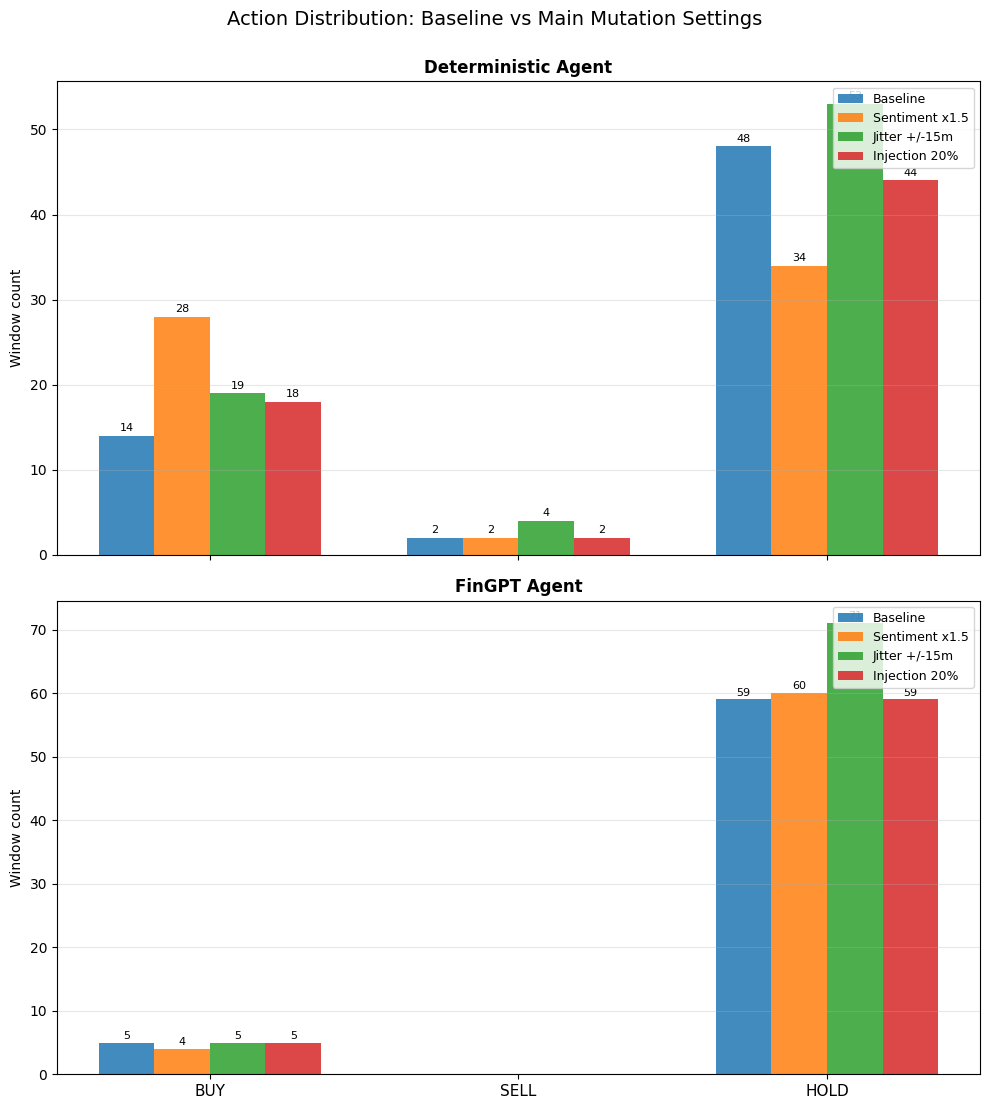

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/l3_action_distribution_vertical.png


In [27]:
# Change subplots to 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True)

plot_order = MAIN_DATASET_ORDER
for ax, (agent_name, trajs, title) in zip(axes, [
    ('deterministic', det_trajectories, 'Deterministic Agent'),
    ('fingpt',        fingpt_trajectories, 'FinGPT Agent'),
]):
    x, w = np.arange(len(ACTIONS)), 0.18
    for di, ds in enumerate(plot_order):
        cnts = trajs[ds]['action_taken'].value_counts()
        vals = [int(cnts.get(a, 0)) for a in ACTIONS]
        # Calculate offset for grouped bar chart
        offset = (di - len(plot_order)/2 + 0.5) * w
        bars = ax.bar(x + offset, vals, w, label=DATASET_LABELS[ds], alpha=0.85)

        # Add value labels on top of bars
        for bar, val in zip(bars, vals):
            if val > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.3,
                        str(val), ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(ACTIONS, fontsize=11)
    ax.set_ylabel('Window count')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

# Overall Title
plt.suptitle('Action Distribution: Baseline vs Main Mutation Settings', fontsize=14, y=0.95)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle

p = PLOT_DIR / 'l3_action_distribution_vertical.png'
plt.savefig(p, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


### Step 12A: Action Distribution by Mutation Family

The main Step 12 plot compares baseline against the middle setting from each mutation family. These plots compare action distributions within each family sweep: baseline plus all sentiment factors, all jitter strengths, and all injection ratios.


=== Action Distribution by Mutation Family ===


,family,dataset,label,strength,agent,action_taken,count,percent
0,sentiment,baseline,Baseline,0.00,deterministic,BUY,14,21.88
1,sentiment,baseline,Baseline,0.00,deterministic,SELL,2,3.12
2,sentiment,baseline,Baseline,0.00,deterministic,HOLD,48,75.00
3,sentiment,baseline,Baseline,0.00,fingpt,BUY,5,7.81
4,sentiment,baseline,Baseline,0.00,fingpt,SELL,0,0.00
...,...,...,...,...,...,...,...,...
67,injection,injection_0.35,Injection 35%,0.35,deterministic,SELL,2,3.12
68,injection,injection_0.35,Injection 35%,0.35,deterministic,HOLD,44,68.75
69,injection,injection_0.35,Injection 35%,0.35,fingpt,BUY,5,7.81
70,injection,injection_0.35,Injection 35%,0.35,fingpt,SELL,0,0.00


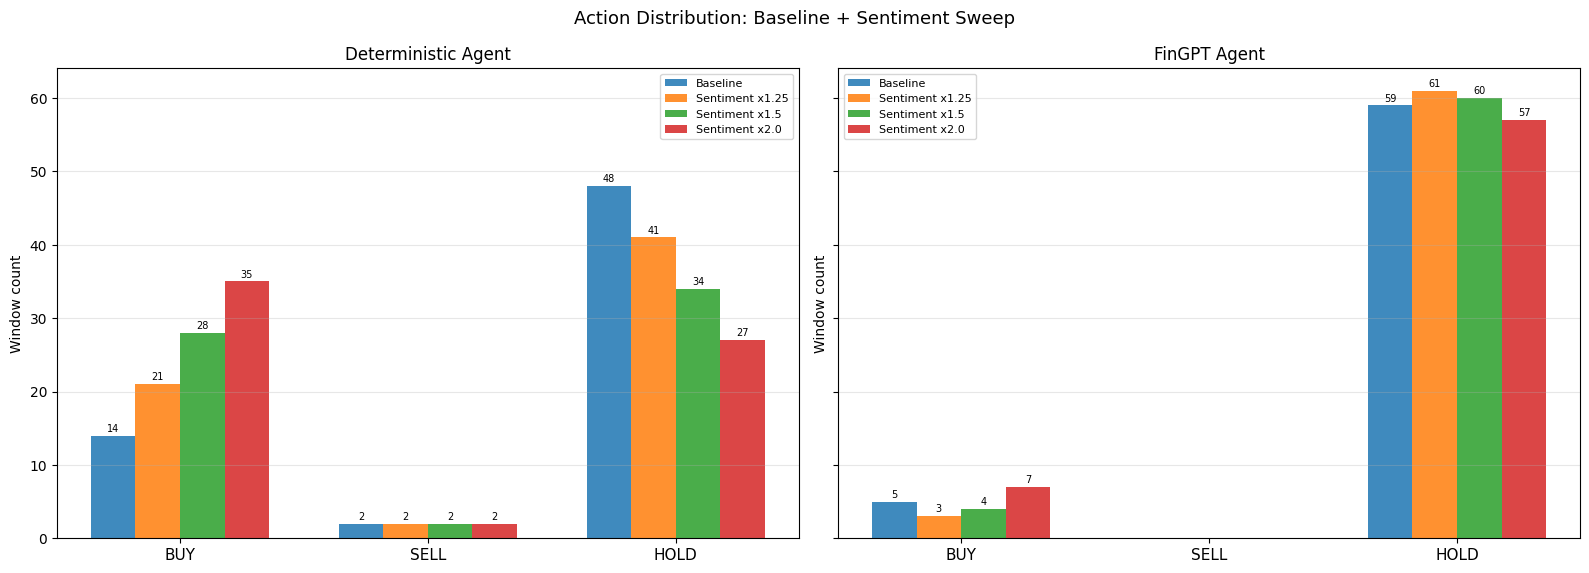

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/l3_action_distribution_sentiment_sweep.png


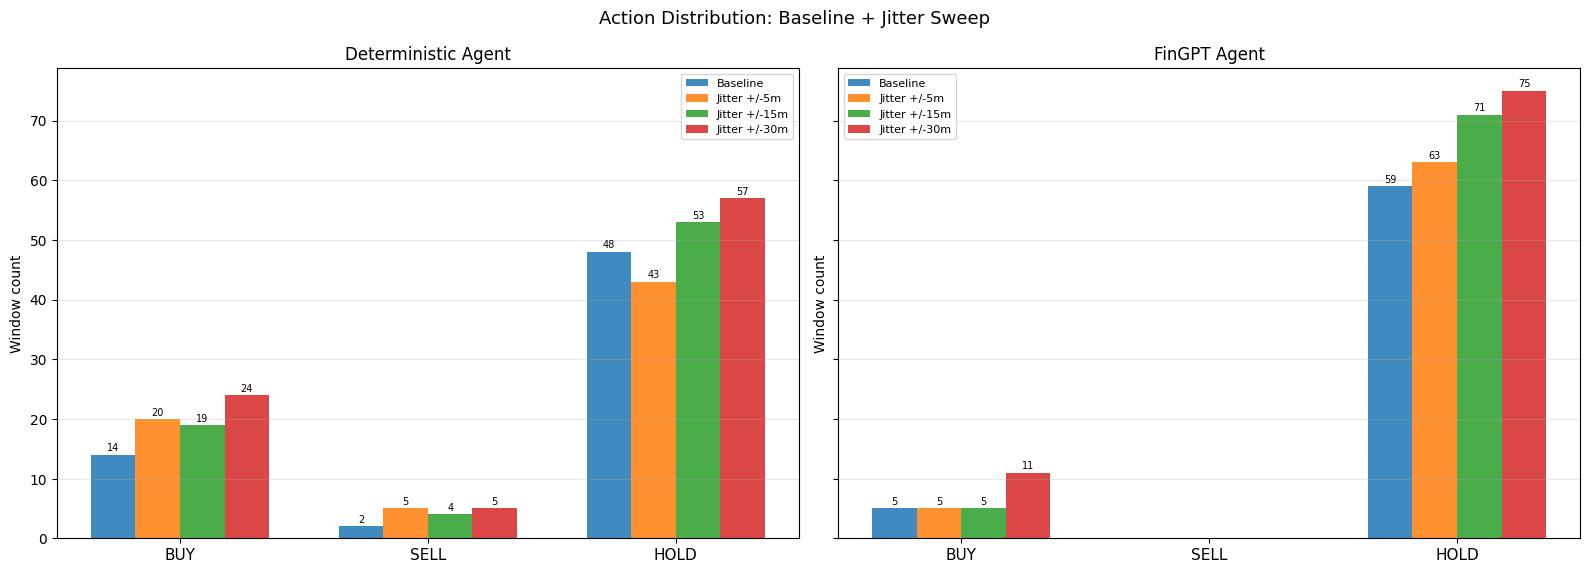

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/l3_action_distribution_jitter_sweep.png


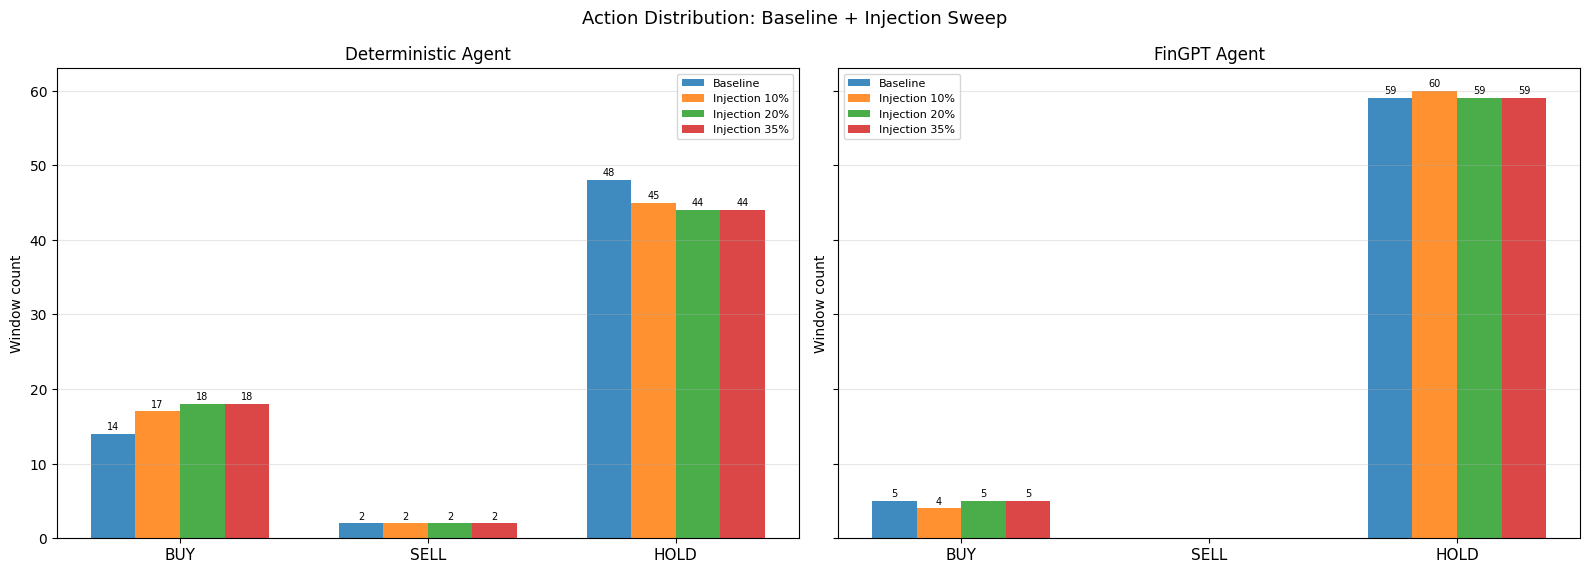

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/l3_action_distribution_injection_sweep.png


In [28]:
FAMILY_ACTION_ORDERS = {
    'sentiment': ['baseline'] + [sentiment_dataset_key(factor) for factor in SENTIMENT_FACTORS],
    'jitter': ['baseline'] + [jitter_dataset_key(max_minutes) for max_minutes in JITTER_MAX_MINUTES_LIST],
    'injection': ['baseline'] + [injection_dataset_key(ratio) for ratio in INJECTION_RATIOS],
}

family_action_rows = []
for family, datasets in FAMILY_ACTION_ORDERS.items():
    for dataset in datasets:
        meta = DATASET_META[dataset]
        for agent_name, trajs in [('deterministic', det_trajectories), ('fingpt', fingpt_trajectories)]:
            df = trajs[dataset]
            total = len(df)
            counts = df['action_taken'].value_counts()
            for action in ACTIONS:
                count = int(counts.get(action, 0))
                family_action_rows.append({
                    'family': family,
                    'dataset': dataset,
                    'label': meta['label'],
                    'strength': meta['strength'],
                    'agent': agent_name,
                    'action_taken': action,
                    'count': count,
                    'percent': round(count / total * 100, 2) if total else 0.0,
                })

family_action_distribution = pd.DataFrame(family_action_rows)
family_action_distribution.to_csv(TABLE_DIR / 'family_action_distribution.csv', index=False)

print('=== Action Distribution by Mutation Family ===')
display(family_action_distribution)

for family, datasets in FAMILY_ACTION_ORDERS.items():
    fig, axes = plt.subplots(1, 2, figsize=(16, 5.8), sharey=True)
    width = min(0.18, 0.78 / max(len(datasets), 1))
    x = np.arange(len(ACTIONS))

    for ax, (agent_name, trajs, title) in zip(axes, [
        ('deterministic', det_trajectories, 'Deterministic Agent'),
        ('fingpt',        fingpt_trajectories, 'FinGPT Agent'),
    ]):
        for di, dataset in enumerate(datasets):
            cnts = trajs[dataset]['action_taken'].value_counts()
            vals = [int(cnts.get(action, 0)) for action in ACTIONS]
            offset = (di - len(datasets) / 2 + 0.5) * width
            bars = ax.bar(x + offset, vals, width, label=DATASET_LABELS[dataset], alpha=0.86)
            for bar, val in zip(bars, vals):
                if val > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + 0.3,
                        str(val),
                        ha='center',
                        va='bottom',
                        fontsize=7,
                    )
        ax.set_xticks(x)
        ax.set_xticklabels(ACTIONS, fontsize=11)
        ax.set_ylabel('Window count')
        ax.set_title(title, fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        ax.legend(fontsize=8)

    plt.suptitle(f'Action Distribution: Baseline + {family.title()} Sweep', fontsize=13)
    plt.tight_layout()
    p = PLOT_DIR / f'l3_action_distribution_{family}_sweep.png'
    plt.savefig(p, dpi=130, bbox_inches='tight')
    plt.show()
    print(f'Saved: {p}')


### Step 12B: Prompt Ablation Result Snapshot

This is a recorded snapshot from the earlier prompt-ablation run. It is intentionally static and does not rerun FinGPT during the full parameter-sweep notebook execution.


=== Prompt Ablation Design and Result Summary ===


,prompt_name,design_goal,input_change,observed_behavior,BUY,HOLD,SELL,total_windows,sell_rate_%
0,current_aggregate,Control prompt,Original aggregate window summary only,Most balanced; BUY/HOLD only,23,241,0,264,0.0
1,raw_scores,Expose tweet-level score distribution,Adds raw sentiment scores and quantiles,Mostly HOLD; more conservative,4,260,0,264,0.0
2,rule_calibrated,Align prompt with deterministic thresholds,Adds explicit BUY/SELL/HOLD policy thresholds,All HOLD,0,264,0,264,0.0
3,fewshot_balanced,Reduce HOLD/BUY bias with examples,"Adds one BUY, one SELL, and one HOLD example",Mostly BUY; prompt-frame collapse,255,9,0,264,0.0


=== Prompt Ablation Action Counts by Dataset ===


,prompt_name,dataset,action_taken,count,total,percent
0,current_aggregate,baseline,BUY,8,64,12.50
1,current_aggregate,baseline,SELL,0,64,0.00
2,current_aggregate,baseline,HOLD,56,64,87.50
3,current_aggregate,sentiment_mutation,BUY,4,64,6.25
4,current_aggregate,sentiment_mutation,SELL,0,64,0.00
5,current_aggregate,sentiment_mutation,HOLD,60,64,93.75
6,current_aggregate,temporal_jitter,BUY,5,72,6.94
7,current_aggregate,temporal_jitter,SELL,0,72,0.00
8,current_aggregate,temporal_jitter,HOLD,67,72,93.06
9,current_aggregate,adversarial,BUY,6,64,9.38


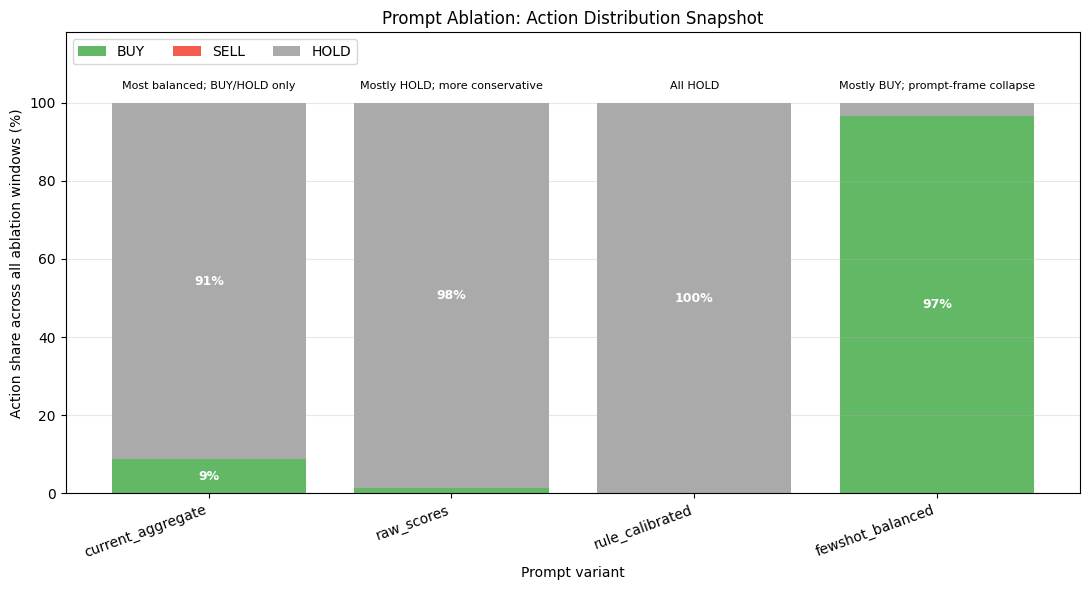

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/prompt_ablation_action_distribution.png


In [29]:
PROMPT_ABLATION_COUNTS = {
    'current_aggregate': {
        'baseline': {'BUY': 8, 'HOLD': 56, 'SELL': 0},
        'sentiment_mutation': {'BUY': 4, 'HOLD': 60, 'SELL': 0},
        'temporal_jitter': {'BUY': 5, 'HOLD': 67, 'SELL': 0},
        'adversarial': {'BUY': 6, 'HOLD': 58, 'SELL': 0},
    },
    'raw_scores': {
        'baseline': {'BUY': 1, 'HOLD': 63, 'SELL': 0},
        'sentiment_mutation': {'BUY': 0, 'HOLD': 64, 'SELL': 0},
        'temporal_jitter': {'BUY': 1, 'HOLD': 71, 'SELL': 0},
        'adversarial': {'BUY': 2, 'HOLD': 62, 'SELL': 0},
    },
    'rule_calibrated': {
        'baseline': {'BUY': 0, 'HOLD': 64, 'SELL': 0},
        'sentiment_mutation': {'BUY': 0, 'HOLD': 64, 'SELL': 0},
        'temporal_jitter': {'BUY': 0, 'HOLD': 72, 'SELL': 0},
        'adversarial': {'BUY': 0, 'HOLD': 64, 'SELL': 0},
    },
    'fewshot_balanced': {
        'baseline': {'BUY': 64, 'HOLD': 0, 'SELL': 0},
        'sentiment_mutation': {'BUY': 64, 'HOLD': 0, 'SELL': 0},
        'temporal_jitter': {'BUY': 71, 'HOLD': 1, 'SELL': 0},
        'adversarial': {'BUY': 56, 'HOLD': 8, 'SELL': 0},
    },
}

PROMPT_ABLATION_DESIGN = {
    'current_aggregate': {
        'design_goal': 'Control prompt',
        'input_change': 'Original aggregate window summary only',
        'observed_behavior': 'Most balanced; BUY/HOLD only',
    },
    'raw_scores': {
        'design_goal': 'Expose tweet-level score distribution',
        'input_change': 'Adds raw sentiment scores and quantiles',
        'observed_behavior': 'Mostly HOLD; more conservative',
    },
    'rule_calibrated': {
        'design_goal': 'Align prompt with deterministic thresholds',
        'input_change': 'Adds explicit BUY/SELL/HOLD policy thresholds',
        'observed_behavior': 'All HOLD',
    },
    'fewshot_balanced': {
        'design_goal': 'Reduce HOLD/BUY bias with examples',
        'input_change': 'Adds one BUY, one SELL, and one HOLD example',
        'observed_behavior': 'Mostly BUY; prompt-frame collapse',
    },
}

prompt_action_rows = []
for prompt_name, dataset_counts in PROMPT_ABLATION_COUNTS.items():
    for dataset, counts in dataset_counts.items():
        total = sum(int(counts.get(action, 0)) for action in ACTIONS)
        for action in ACTIONS:
            count = int(counts.get(action, 0))
            prompt_action_rows.append({
                'prompt_name': prompt_name,
                'dataset': dataset,
                'action_taken': action,
                'count': count,
                'total': total,
                'percent': round(count / total * 100, 2) if total else 0.0,
            })

prompt_ablation_action_counts = pd.DataFrame(prompt_action_rows)
prompt_ablation_action_counts.to_csv(TABLE_DIR / 'prompt_ablation_action_counts.csv', index=False)

summary_rows = []
for prompt_name, design in PROMPT_ABLATION_DESIGN.items():
    sub = prompt_ablation_action_counts[prompt_ablation_action_counts['prompt_name'] == prompt_name]
    totals = sub.groupby('action_taken')['count'].sum().to_dict()
    total_windows = int(sub.drop_duplicates(['prompt_name', 'dataset'])['total'].sum())
    buy = int(totals.get('BUY', 0))
    hold = int(totals.get('HOLD', 0))
    sell = int(totals.get('SELL', 0))
    summary_rows.append({
        'prompt_name': prompt_name,
        'design_goal': design['design_goal'],
        'input_change': design['input_change'],
        'observed_behavior': design['observed_behavior'],
        'BUY': buy,
        'HOLD': hold,
        'SELL': sell,
        'total_windows': total_windows,
        'sell_rate_%': round(sell / total_windows * 100, 2) if total_windows else 0.0,
    })

prompt_ablation_summary = pd.DataFrame(summary_rows)
prompt_ablation_summary.to_csv(TABLE_DIR / 'prompt_ablation_summary.csv', index=False)

print('=== Prompt Ablation Design and Result Summary ===')
display(prompt_ablation_summary)
print('=== Prompt Ablation Action Counts by Dataset ===')
display(prompt_ablation_action_counts)

prompt_order = list(PROMPT_ABLATION_COUNTS.keys())
fig, ax = plt.subplots(figsize=(11, 6))
bottom = np.zeros(len(prompt_order))
for action in ACTIONS:
    vals = []
    for prompt_name in prompt_order:
        row = prompt_ablation_summary[prompt_ablation_summary['prompt_name'] == prompt_name].iloc[0]
        vals.append(float(row[action]) / float(row['total_windows']) * 100 if row['total_windows'] else 0.0)
    ax.bar(prompt_order, vals, bottom=bottom, color=ACTION_COLORS[action], label=action, alpha=0.88)
    for xi, (start, val) in enumerate(zip(bottom, vals)):
        if val >= 6:
            ax.text(xi, start + val / 2, f'{val:.0f}%', ha='center', va='center', fontsize=9, color='white', fontweight='bold')
    bottom += np.array(vals)

for xi, prompt_name in enumerate(prompt_order):
    behavior = PROMPT_ABLATION_DESIGN[prompt_name]['observed_behavior']
    ax.text(xi, 103, behavior, ha='center', va='bottom', fontsize=8, rotation=0)

ax.set_ylim(0, 118)
ax.set_ylabel('Action share across all ablation windows (%)')
ax.set_xlabel('Prompt variant')
ax.set_title('Prompt Ablation: Action Distribution Snapshot')
ax.set_xticks(np.arange(len(prompt_order)))
ax.set_xticklabels(prompt_order, rotation=20, ha='right')
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left', ncol=3)
plt.tight_layout()
p = PLOT_DIR / 'prompt_ablation_action_distribution.png'
plt.savefig(p, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')


The prompt ablation did not create SELL diversity. The original aggregate prompt remained the most balanced among the tested prompts, while raw-score and rule-calibrated prompts became more conservative and collapsed mostly to HOLD. The few-shot prompt showed the opposite failure mode, collapsing toward BUY. This supports the interpretation that prompt wording alone is not enough to recover SELL actions when the underlying data has very few strongly negative windows.


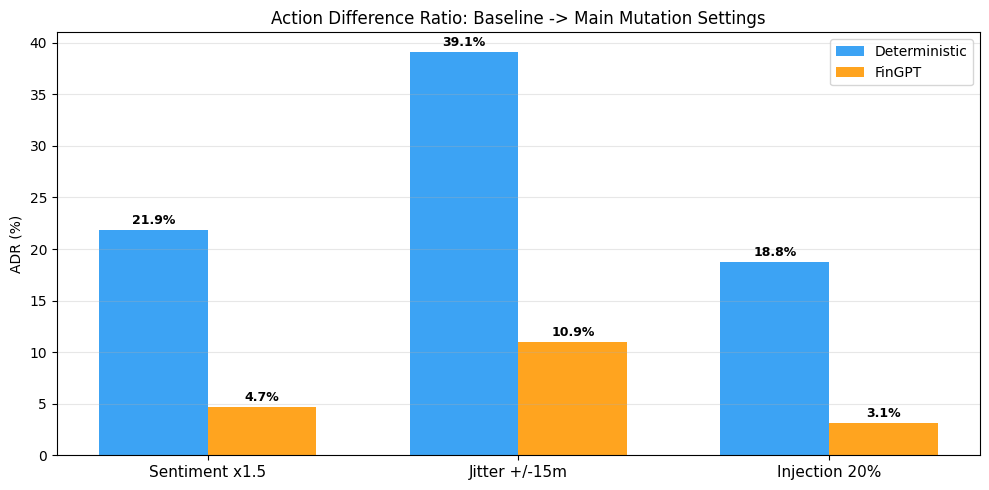

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/l3_adr_comparison.png


In [30]:
main_mut_names = [d for d in MAIN_DATASET_ORDER if d != 'baseline']
det_adrs  = [compute_adr(det_trajectories['baseline'], det_trajectories[m])['adr'] * 100 for m in main_mut_names]
fgpt_adrs = [compute_adr(fingpt_trajectories['baseline'], fingpt_trajectories[m])['adr'] * 100 for m in main_mut_names]

fig, ax = plt.subplots(figsize=(10, 5))
x, w = np.arange(len(main_mut_names)), 0.35
b1 = ax.bar(x-w/2, det_adrs,  w, label='Deterministic', color=AGENT_COLORS['deterministic'], alpha=0.88)
b2 = ax.bar(x+w/2, fgpt_adrs, w, label='FinGPT',        color=AGENT_COLORS['fingpt'],        alpha=0.88)
for bar in list(b1)+list(b2):
    h = bar.get_height()
    ax.text(bar.get_x()+bar.get_width()/2, h+0.3, f'{h:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([DATASET_LABELS[m] for m in main_mut_names], fontsize=11)
ax.set_ylabel('ADR (%)')
ax.set_title('Action Difference Ratio: Baseline -> Main Mutation Settings', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
p = PLOT_DIR / 'l3_adr_comparison.png'
plt.savefig(p, dpi=130, bbox_inches='tight'); plt.show(); print(f'Saved: {p}')


## Step 13: Plot -- Decision Trajectory Timeline

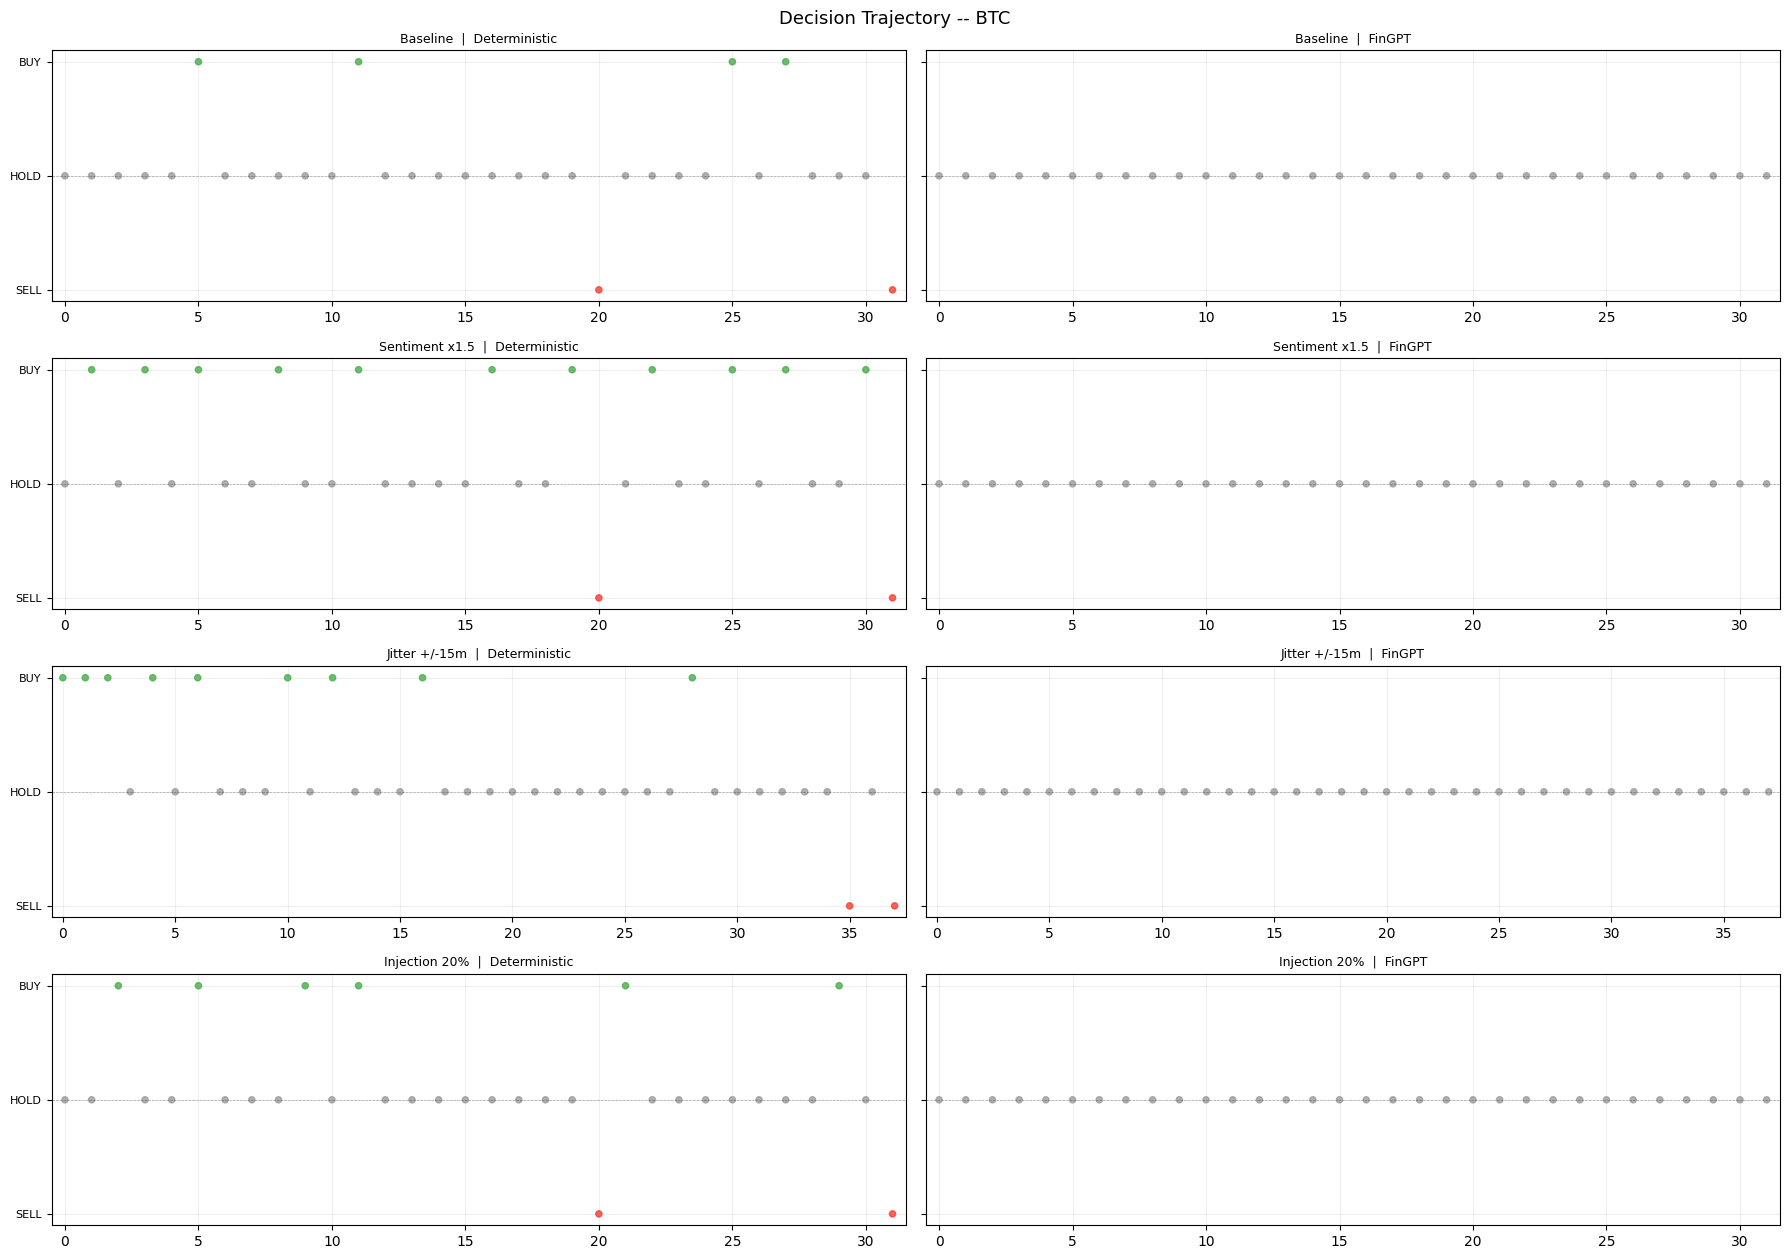

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/l3_timeline_btc.png


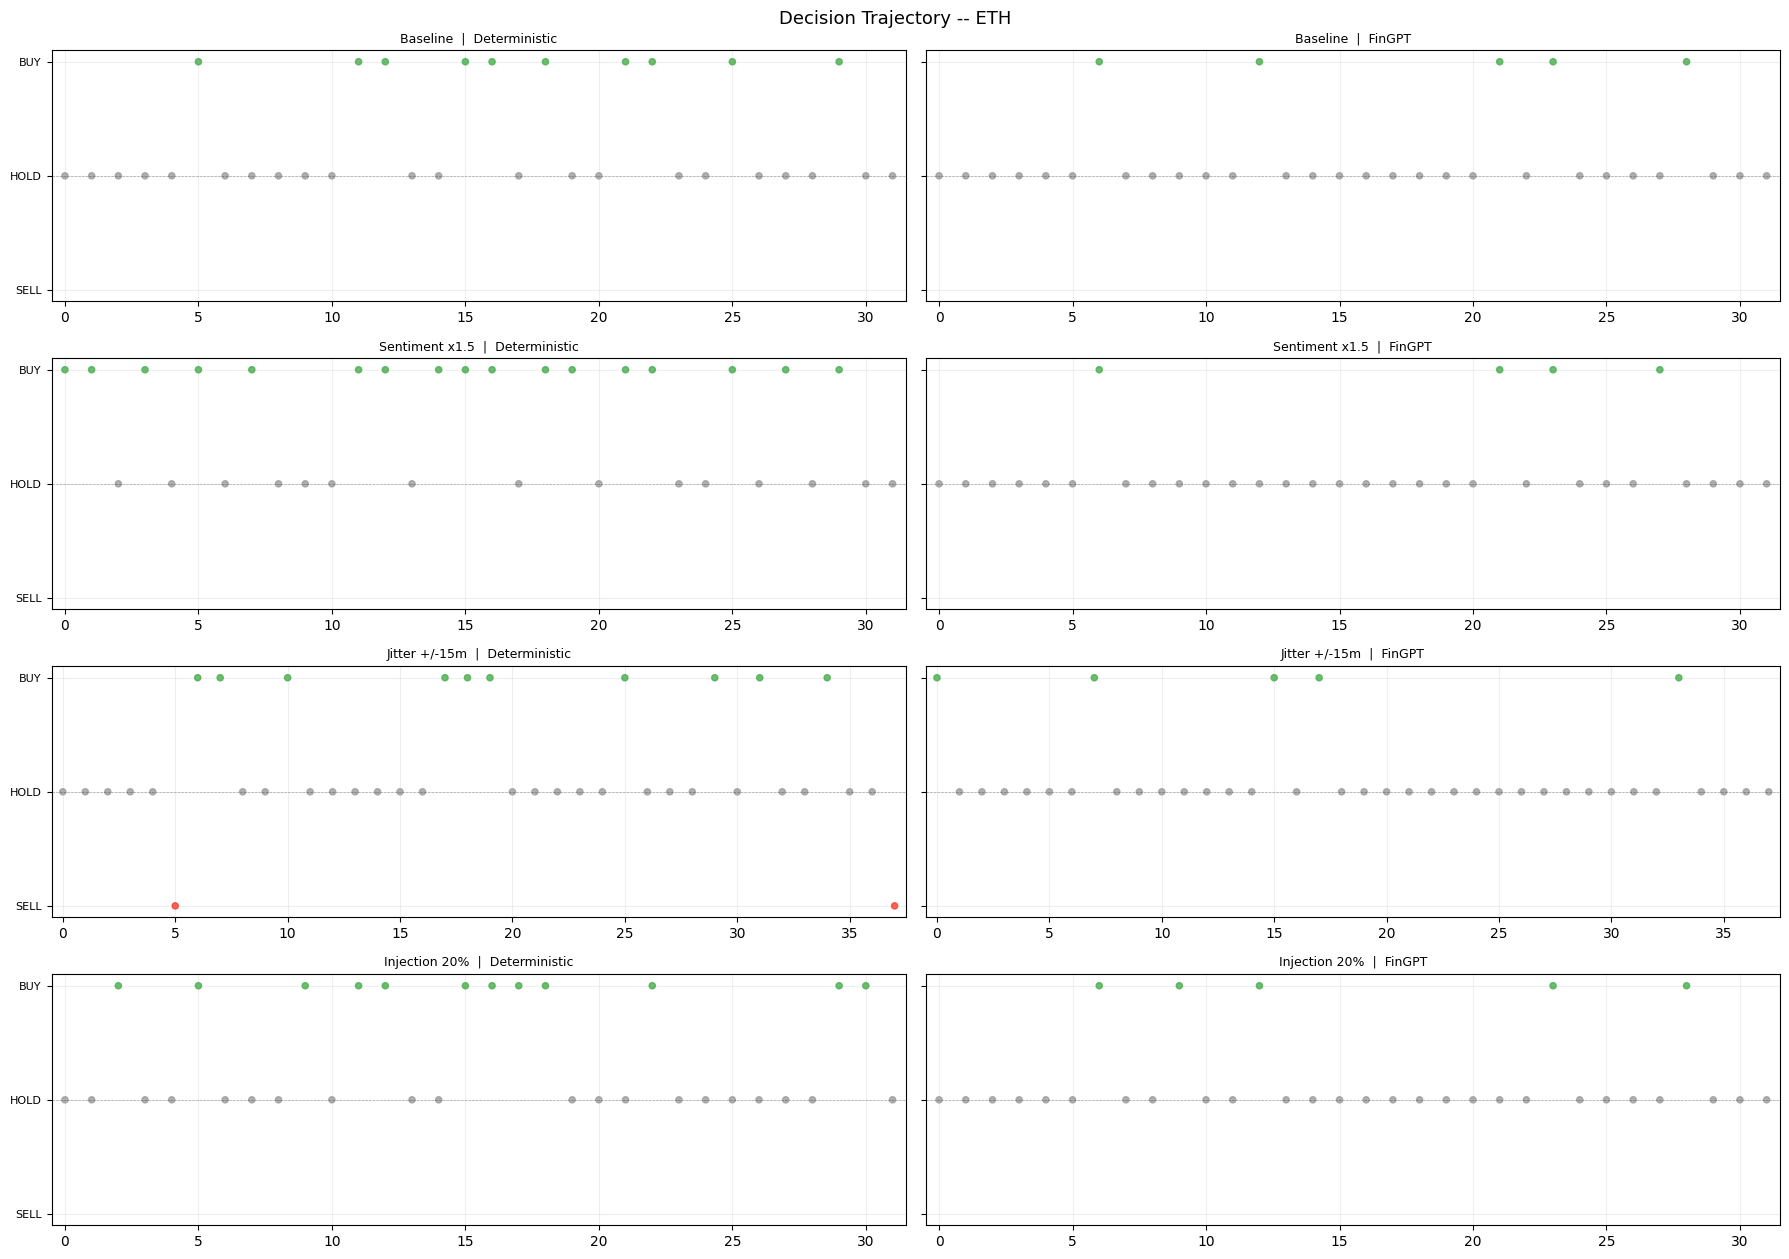

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/l3_timeline_eth.png


In [31]:
action_num = {'BUY': 1, 'HOLD': 0, 'SELL': -1}
plot_order = MAIN_DATASET_ORDER

for coin in ['BTC', 'ETH']:
    n_ds = len(plot_order)
    fig, axes = plt.subplots(n_ds, 2, figsize=(18, 3.2*n_ds), sharey=True)
    if n_ds == 1:
        axes = np.array([axes])
    fig.suptitle(f'Decision Trajectory -- {coin}', fontsize=13)

    for ri, ds in enumerate(plot_order):
        for ci, (agent_name, trajs) in enumerate([
            ('Deterministic', det_trajectories),
            ('FinGPT',        fingpt_trajectories),
        ]):
            ax  = axes[ri][ci]
            df  = trajs[ds][trajs[ds]['cryptocurrency']==coin].sort_values('window_start')
            steps  = np.arange(len(df))
            vals   = df['action_taken'].map(action_num).values
            colors = [ACTION_COLORS.get(a,'#9E9E9E') for a in df['action_taken']]
            ax.scatter(steps, vals, c=colors, s=20, alpha=0.82, zorder=2)
            ax.axhline(0, color='black', lw=0.5, ls='--', alpha=0.3)
            ax.set_yticks([-1,0,1])
            ax.set_yticklabels(['SELL','HOLD','BUY'], fontsize=8)
            ax.set_title(f"{DATASET_LABELS[ds]}  |  {agent_name}", fontsize=9)
            ax.grid(alpha=0.2); ax.set_xlim(-0.5, max(len(df)-0.5, 1))

    plt.tight_layout()
    p = PLOT_DIR / f'l3_timeline_{coin.lower()}.png'
    plt.savefig(p, dpi=120, bbox_inches='tight'); plt.show(); print(f'Saved: {p}')


## Step 14: Plot -- Rule vs FinGPT Agreement Matrix

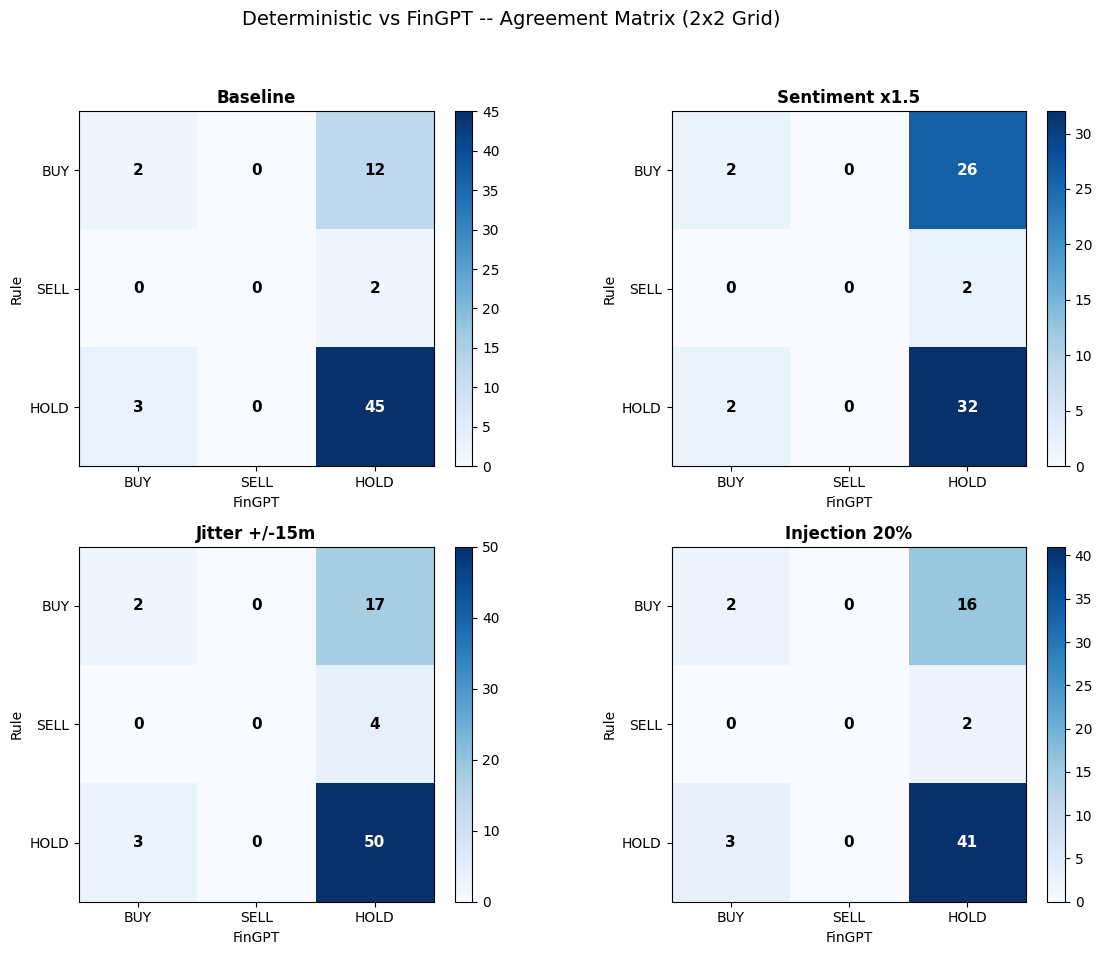

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/l3_agreement_matrix_grid.png


In [32]:
plot_order = MAIN_DATASET_ORDER[:4]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes_flat = axes.flatten()

for i, ds in enumerate(plot_order):
    ax = axes_flat[i]
    rule_a = det_trajectories[ds]['action_taken']
    fgpt_a = fingpt_trajectories[ds]['action_taken']

    matrix = pd.crosstab(rule_a.rename('Rule'), fgpt_a.rename('FinGPT')).reindex(index=ACTIONS, columns=ACTIONS, fill_value=0)

    im = ax.imshow(matrix.values, cmap='Blues', vmin=0)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(ACTIONS, fontsize=10); ax.set_yticklabels(ACTIONS, fontsize=10)
    ax.set_xlabel('FinGPT', fontsize=10); ax.set_ylabel('Rule', fontsize=10)
    ax.set_title(DATASET_LABELS[ds], fontsize=12, fontweight='bold')

    max_v = max(matrix.values.max(), 1)
    for row in range(3):
        for col in range(3):
            v = matrix.values[row, col]
            ax.text(col, row, str(v), ha='center', va='center',
                    color='white' if v > max_v*0.55 else 'black',
                    fontsize=11, fontweight='bold')

for j in range(i + 1, len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.suptitle('Deterministic vs FinGPT -- Agreement Matrix (2x2 Grid)', fontsize=14, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])

p = PLOT_DIR / 'l3_agreement_matrix_grid.png'
plt.savefig(p, dpi=130, bbox_inches='tight')
plt.show()
print(f'Saved: {p}')

## Step 15: Adversarial Injection Flip Analysis

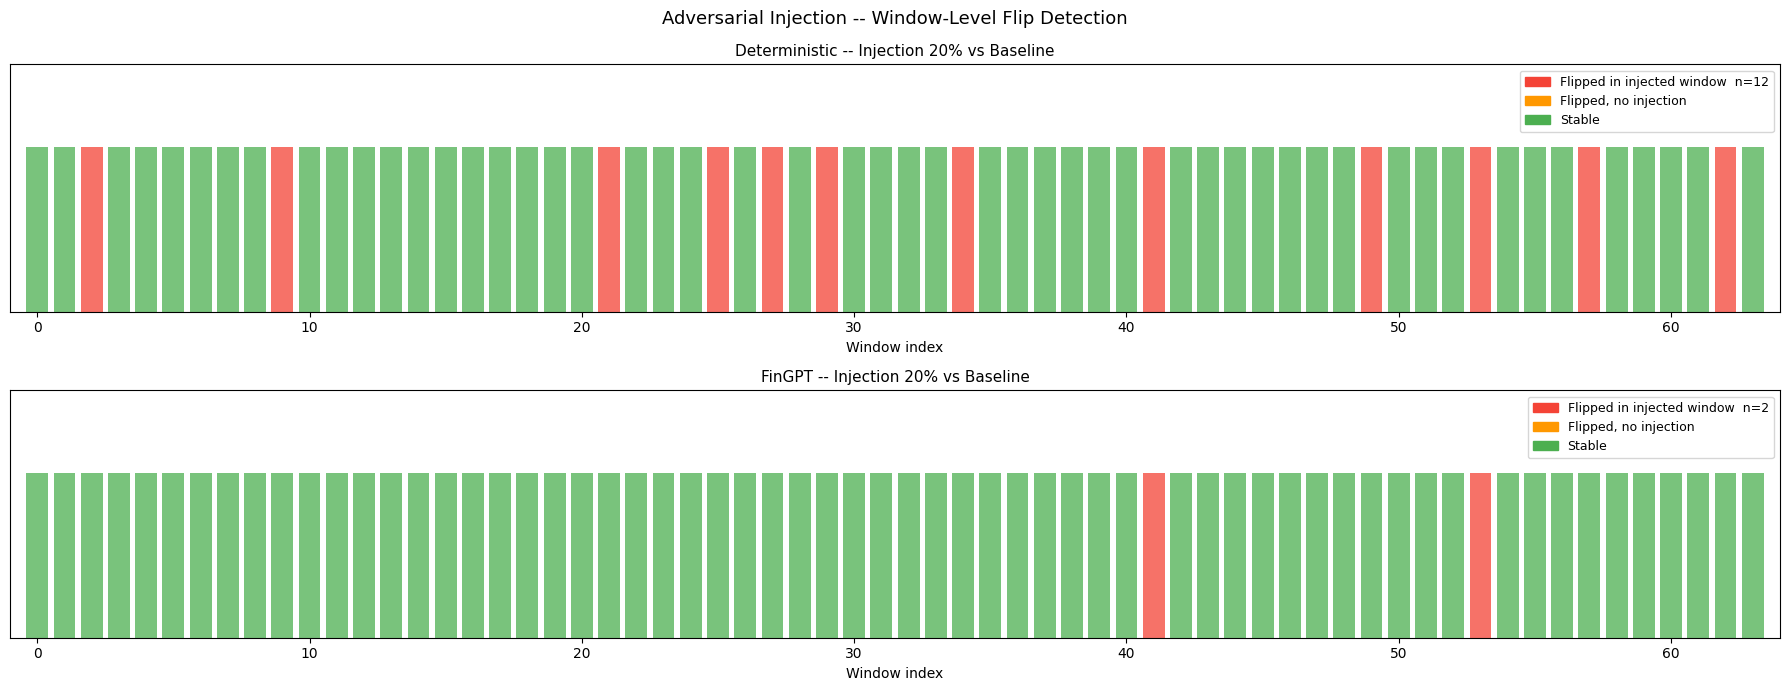

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/l3_adversarial_flip.png
=== Adversarial Injected-Window Flip Rate by Injection Ratio ===


,dataset,family,strength,label,is_main,matched_windows,targeted_windows,flipped_targeted,targeted_flip_rate_%,flipped_all,all_flip_rate_%,agent
0,injection_0.10,injection,0.10,Injection 10%,False,64,16,11,68.75,11,17.19,deterministic
1,injection_0.10,injection,0.10,Injection 10%,False,64,16,1,6.25,1,1.56,fingpt
2,injection_0.20,injection,0.20,Injection 20%,True,64,16,12,75.00,12,18.75,deterministic
3,injection_0.20,injection,0.20,Injection 20%,True,64,16,2,12.50,2,3.12,fingpt
4,injection_0.35,injection,0.35,Injection 35%,False,64,16,12,75.00,12,18.75,deterministic
5,injection_0.35,injection,0.35,Injection 35%,False,64,16,2,12.50,2,3.12,fingpt


In [33]:
def compute_injected_flip_summary(trajs, dataset):
    base = trajs['baseline'][['window_id','cryptocurrency','action_taken']]
    adv = trajs[dataset][['window_id','cryptocurrency','action_taken','synthetic_count']]
    merged = base.merge(adv, on=['window_id','cryptocurrency'], suffixes=('_base','_adv'))
    merged['flipped'] = merged['action_taken_base'] != merged['action_taken_adv']
    merged['has_injection'] = merged['synthetic_count'] > 0
    targeted = merged[merged['has_injection']]
    return {
        'matched_windows': int(len(merged)),
        'targeted_windows': int(len(targeted)),
        'flipped_targeted': int(targeted['flipped'].sum()),
        'targeted_flip_rate_%': round(float(targeted['flipped'].mean() * 100), 2) if len(targeted) else 0.0,
        'flipped_all': int(merged['flipped'].sum()),
        'all_flip_rate_%': round(float(merged['flipped'].mean() * 100), 2) if len(merged) else 0.0,
        'merged': merged,
    }

main_injection_dataset = injection_dataset_key(MAIN_INJECTION_RATIO)
fig, axes = plt.subplots(2, 1, figsize=(18, 7))
for ax, (agent_name, trajs) in zip(axes, [
    ('Deterministic', det_trajectories),
    ('FinGPT',        fingpt_trajectories),
]):
    result = compute_injected_flip_summary(trajs, main_injection_dataset)
    merged = result['merged']

    colors = []
    for _, row in merged.iterrows():
        if row['flipped'] and row['has_injection']:  colors.append('#F44336')
        elif row['flipped']:                          colors.append('#FF9800')
        else:                                         colors.append('#4CAF50')

    ax.bar(np.arange(len(merged)), [1]*len(merged), color=colors, alpha=0.75)
    ax.set_xlim(-1, len(merged)); ax.set_ylim(0, 1.5); ax.set_yticks([])
    ax.set_title(f'{agent_name} -- {DATASET_LABELS[main_injection_dataset]} vs Baseline', fontsize=11)
    ax.set_xlabel('Window index')
    ax.legend(handles=[
        mpatches.Patch(color='#F44336', label=f"Flipped in injected window  n={result['flipped_targeted']}"),
        mpatches.Patch(color='#FF9800', label='Flipped, no injection'),
        mpatches.Patch(color='#4CAF50', label='Stable'),
    ], loc='upper right', fontsize=9)

plt.suptitle('Adversarial Injection -- Window-Level Flip Detection', fontsize=13)
plt.tight_layout()
p = PLOT_DIR / 'l3_adversarial_flip.png'
plt.savefig(p, dpi=130, bbox_inches='tight'); plt.show(); print(f'Saved: {p}')

injection_flip_rows = []
for dataset in [d for d in DATASET_ORDER if DATASET_META[d]['family'] == 'injection']:
    for agent_name, trajs in [('deterministic', det_trajectories), ('fingpt', fingpt_trajectories)]:
        result = compute_injected_flip_summary(trajs, dataset)
        row = dataset_meta_row(dataset)
        row.update({k: v for k, v in result.items() if k != 'merged'})
        row['agent'] = agent_name
        injection_flip_rows.append(row)

injection_flip_table = pd.DataFrame(injection_flip_rows).sort_values(['strength', 'agent']).reset_index(drop=True)
injection_flip_table.to_csv(TABLE_DIR / 'injection_flip_table.csv', index=False)
print('=== Adversarial Injected-Window Flip Rate by Injection Ratio ===')
display(injection_flip_table)


## Step 15A: Sweep Sensitivity Plots


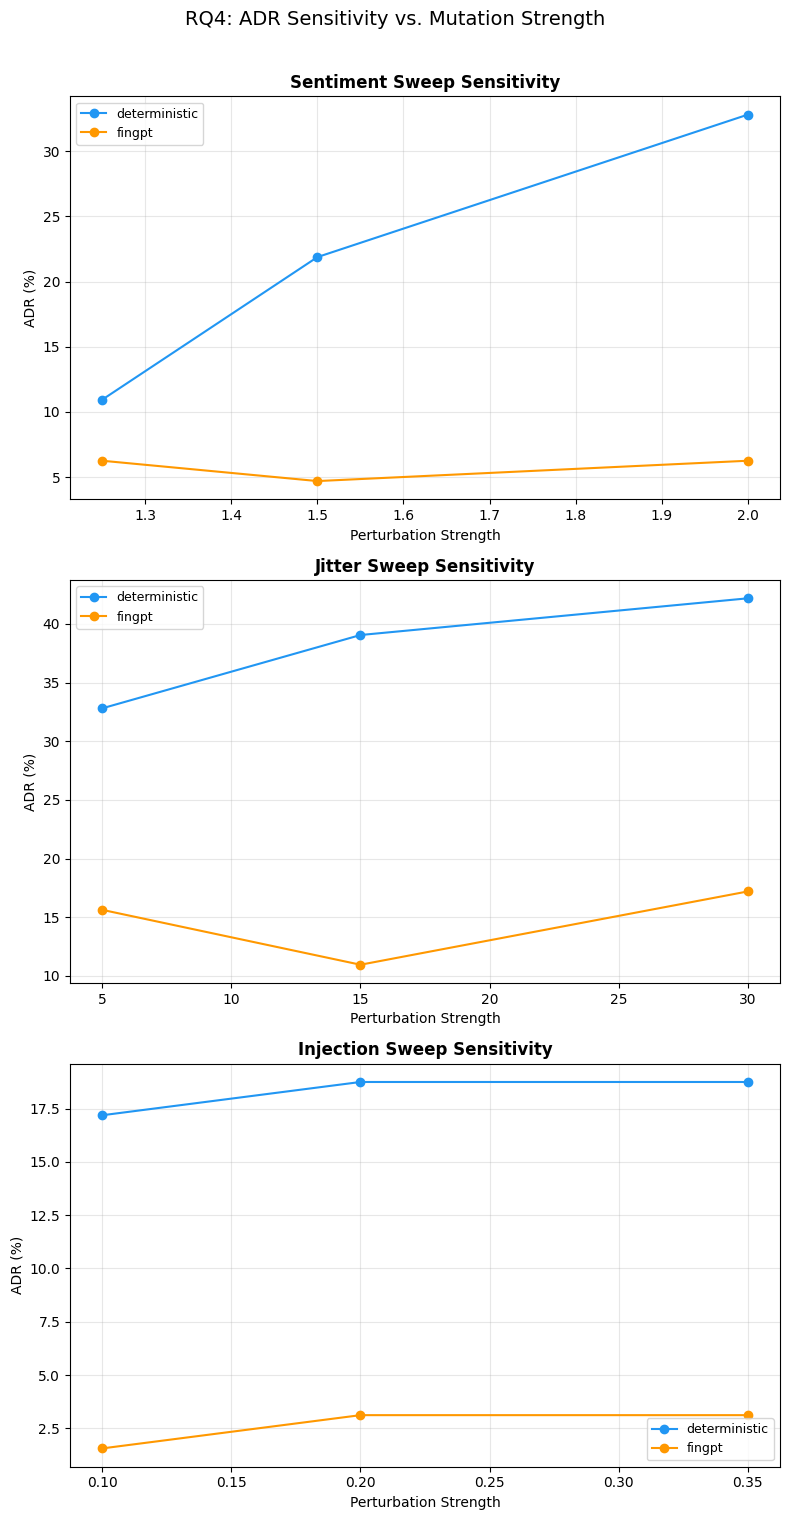

In [34]:
fig, axes = plt.subplots(3, 1, figsize=(8, 15), sharex=False)

for ax, family in zip(axes, SWEEP_FAMILIES):
    sub = sweep_adr_table[sweep_adr_table['family'] == family]
    for agent_name, color in AGENT_COLORS.items():
        ss = sub[sub['agent'] == agent_name].sort_values('strength')
        ax.plot(ss['strength'], ss['ADR_%'], marker='o', label=agent_name, color=color)

    ax.set_title(f'{family.title()} Sweep Sensitivity', fontweight='bold')
    ax.set_xlabel('Perturbation Strength')
    ax.set_ylabel('ADR (%)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='best')

plt.suptitle('RQ4: ADR Sensitivity vs. Mutation Strength', fontsize=14, y=1.01)
plt.tight_layout()
p = PLOT_DIR / 'sweep_adr_vertical.png'
plt.savefig(p, dpi=130, bbox_inches='tight')
plt.show()

=== Actual vs Nominal Injection Ratio ===


,dataset,label,nominal_injection_ratio,windows,mean_actual_ratio,min_actual_ratio,max_actual_ratio,cap_hit_windows,cap_hit_rate_%
0,injection_0.10,Injection 10%,0.10,16,0.103931,0.100529,0.109756,0,0.0
1,injection_0.20,Injection 20%,0.20,16,0.202937,0.200000,0.207792,0,0.0
2,injection_0.35,Injection 35%,0.35,16,0.346310,0.273723,0.361446,2,12.5


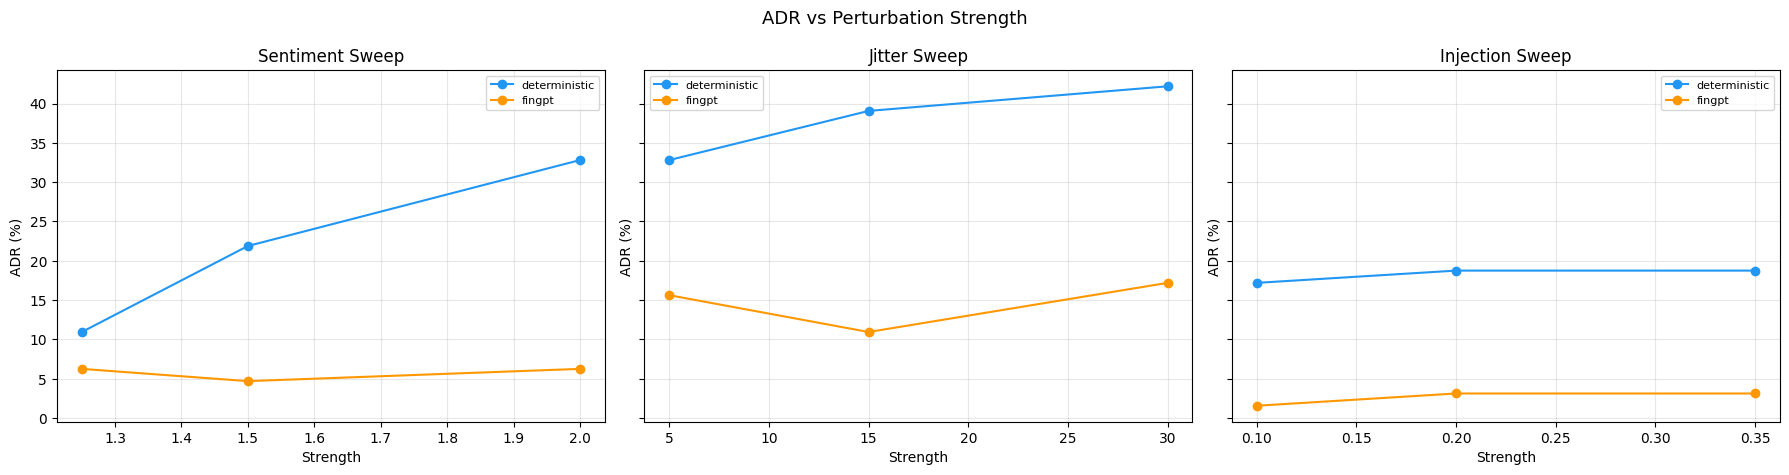

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/sweep_adr_by_strength.png


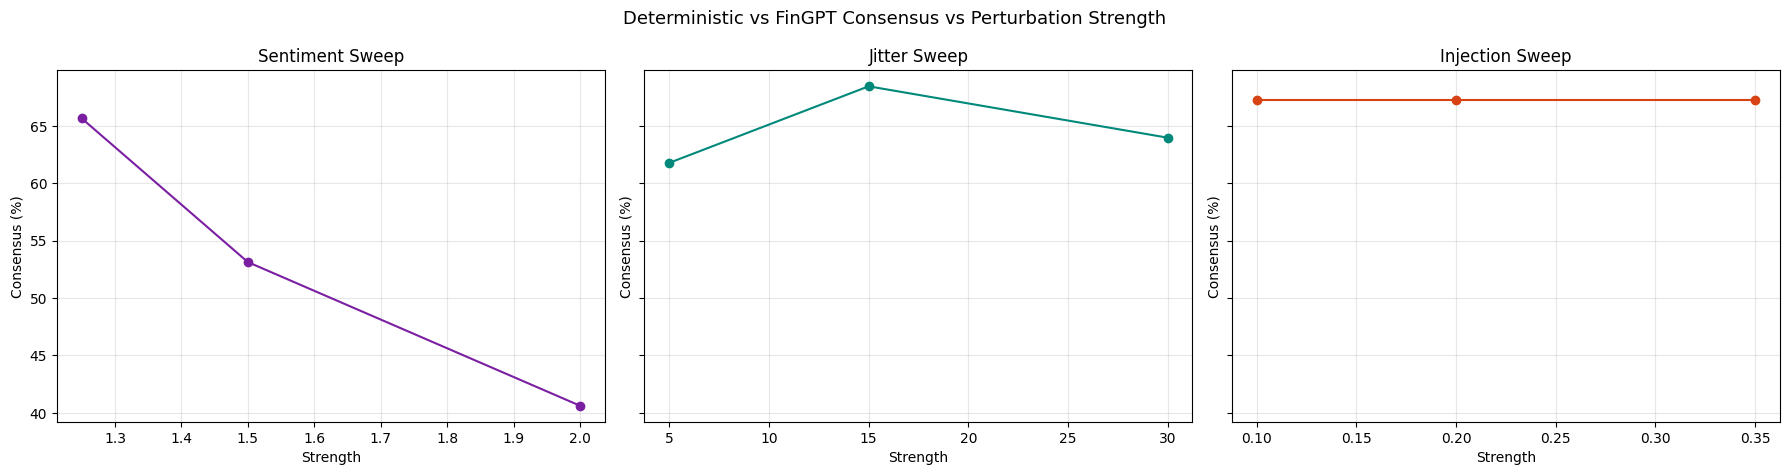

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/sweep_consensus_by_strength.png


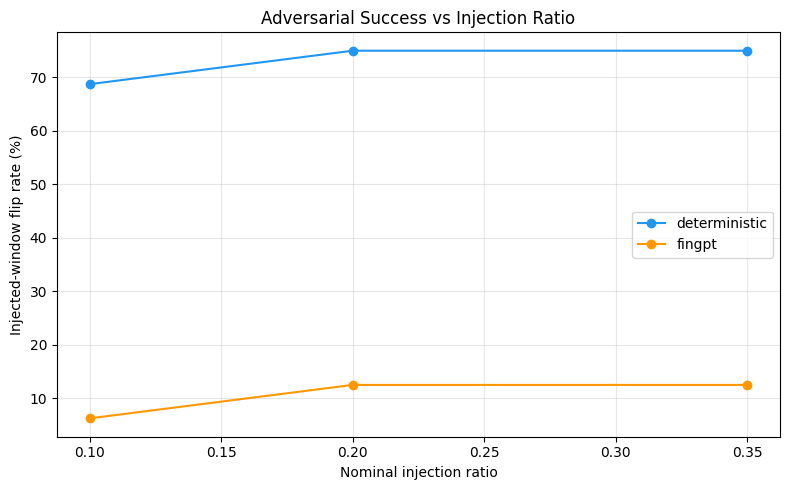

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/sweep_injection_flip_rate.png


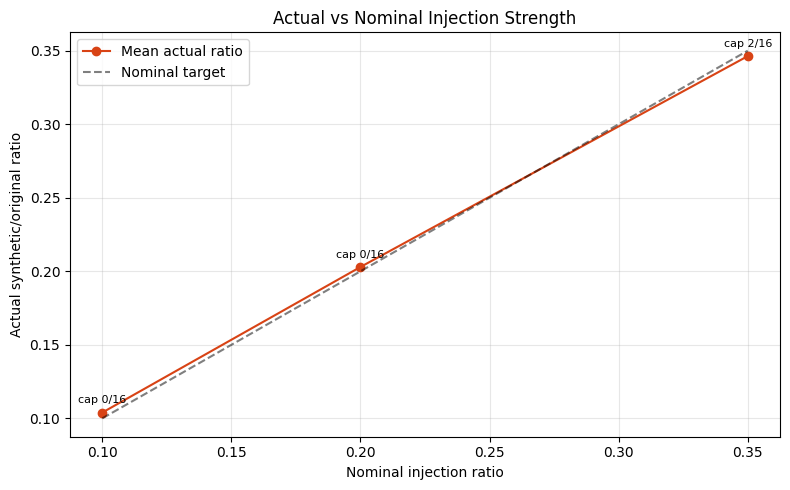

Saved: /content/drive/MyDrive/crypto-drift-guard/data/layer3_outputs/plots/sweep_injection_actual_ratio.png


In [35]:
def build_injection_actual_ratio_table() -> pd.DataFrame:
    rows = []
    for dataset in [d for d in DATASET_ORDER if DATASET_META[d]['family'] == 'injection']:
        wdf = layer1_window_dfs[dataset].copy()
        injected = wdf[pd.to_numeric(wdf['synthetic_count'], errors='coerce').fillna(0) > 0].copy()
        if injected.empty:
            continue
        injected['original_tweet_count'] = injected['tweet_count'] - injected['synthetic_count']
        injected['actual_injection_ratio'] = injected['synthetic_count'] / injected['original_tweet_count']
        injected['cap_hit'] = injected['synthetic_count'] >= MAX_SYNTH_PER_WINDOW
        meta = DATASET_META[dataset]
        for _, row in injected.iterrows():
            rows.append({
                'dataset': dataset,
                'label': meta['label'],
                'nominal_injection_ratio': float(meta['strength']),
                'window_id': row['window_id'],
                'cryptocurrency': row['cryptocurrency'],
                'original_tweet_count': int(row['original_tweet_count']),
                'synthetic_count': int(row['synthetic_count']),
                'actual_injection_ratio': float(row['actual_injection_ratio']),
                'cap_hit': bool(row['cap_hit']),
            })
    return pd.DataFrame(rows)

injection_actual_ratio_table = build_injection_actual_ratio_table()
injection_actual_ratio_table.to_csv(TABLE_DIR / 'injection_actual_ratio_table.csv', index=False)

injection_actual_ratio_summary = (
    injection_actual_ratio_table
    .groupby(['dataset', 'label', 'nominal_injection_ratio'], as_index=False)
    .agg(
        windows=('window_id', 'count'),
        mean_actual_ratio=('actual_injection_ratio', 'mean'),
        min_actual_ratio=('actual_injection_ratio', 'min'),
        max_actual_ratio=('actual_injection_ratio', 'max'),
        cap_hit_windows=('cap_hit', 'sum'),
    )
)
injection_actual_ratio_summary['cap_hit_rate_%'] = (
    injection_actual_ratio_summary['cap_hit_windows'] / injection_actual_ratio_summary['windows'] * 100
).round(2)
injection_actual_ratio_summary.to_csv(TABLE_DIR / 'injection_actual_ratio_summary.csv', index=False)

print('=== Actual vs Nominal Injection Ratio ===')
display(injection_actual_ratio_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)
for ax, family in zip(axes, SWEEP_FAMILIES):
    sub = sweep_adr_table[sweep_adr_table['family'] == family]
    for agent_name, color in AGENT_COLORS.items():
        ss = sub[sub['agent'] == agent_name].sort_values('strength')
        ax.plot(ss['strength'], ss['ADR_%'], marker='o', label=agent_name, color=color)
    ax.set_title(f'{family.title()} Sweep')
    ax.set_xlabel('Strength')
    ax.set_ylabel('ADR (%)')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.suptitle('ADR vs Perturbation Strength', fontsize=13)
plt.tight_layout()
p = PLOT_DIR / 'sweep_adr_by_strength.png'
plt.savefig(p, dpi=130, bbox_inches='tight'); plt.show(); print(f'Saved: {p}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8), sharey=True)
for ax, family in zip(axes, SWEEP_FAMILIES):
    sub = sweep_consensus_table[sweep_consensus_table['family'] == family].sort_values('strength')
    ax.plot(sub['strength'], sub['consensus_%'], marker='o', color=FAMILY_COLORS[family])
    ax.set_title(f'{family.title()} Sweep')
    ax.set_xlabel('Strength')
    ax.set_ylabel('Consensus (%)')
    ax.grid(alpha=0.3)
plt.suptitle('Deterministic vs FinGPT Consensus vs Perturbation Strength', fontsize=13)
plt.tight_layout()
p = PLOT_DIR / 'sweep_consensus_by_strength.png'
plt.savefig(p, dpi=130, bbox_inches='tight'); plt.show(); print(f'Saved: {p}')

fig, ax = plt.subplots(figsize=(8, 5))
for agent_name, color in AGENT_COLORS.items():
    sub = injection_flip_table[injection_flip_table['agent'] == agent_name].sort_values('strength')
    ax.plot(sub['strength'], sub['targeted_flip_rate_%'], marker='o', label=agent_name, color=color)
ax.set_xlabel('Nominal injection ratio')
ax.set_ylabel('Injected-window flip rate (%)')
ax.set_title('Adversarial Success vs Injection Ratio')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
p = PLOT_DIR / 'sweep_injection_flip_rate.png'
plt.savefig(p, dpi=130, bbox_inches='tight'); plt.show(); print(f'Saved: {p}')

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(
    injection_actual_ratio_summary['nominal_injection_ratio'],
    injection_actual_ratio_summary['mean_actual_ratio'],
    marker='o', color=FAMILY_COLORS['injection'], label='Mean actual ratio'
)
ax.plot(
    injection_actual_ratio_summary['nominal_injection_ratio'],
    injection_actual_ratio_summary['nominal_injection_ratio'],
    ls='--', color='black', alpha=0.5, label='Nominal target'
)
for _, row in injection_actual_ratio_summary.iterrows():
    ax.text(row['nominal_injection_ratio'], row['mean_actual_ratio'] + 0.005,
            f"cap {int(row['cap_hit_windows'])}/{int(row['windows'])}",
            ha='center', va='bottom', fontsize=8)
ax.set_xlabel('Nominal injection ratio')
ax.set_ylabel('Actual synthetic/original ratio')
ax.set_title('Actual vs Nominal Injection Strength')
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
p = PLOT_DIR / 'sweep_injection_actual_ratio.png'
plt.savefig(p, dpi=130, bbox_inches='tight'); plt.show(); print(f'Saved: {p}')
